ZAWARD MORISH

REG. NUMBER: 2023/U/MCS/01220

STUDENT NUMBER: 2301201220

In [ ]:
import numpy as np  # For numerical operations and array handling
import pandas as pd  # For loading and handling data from CSV
import matplotlib.pyplot as plt  # For creating visualizations
import seaborn as sns
from sklearn.linear_model import LinearRegression  # For comparison model
from sklearn.metrics import mean_squared_error  # For calculating MSE

# Classifiers
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time
from sklearn.utils import estimator_html_repr
from IPython.display import display, HTML

# Classification models
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import FunctionTransformer
from joblib import load
from joblib import dump

# Statsmodels
from statsmodels.stats.contingency_tables import mcnemar

# OFL-IDS
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report

# imbalanced data
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline  # Special SMOTE-compatible pipeline

# Confusion matrix
from sklearn.metrics import confusion_matrix

In [ ]:
import os
os.makedirs('saved_models', exist_ok=True)

In [ ]:
df = pd.read_csv("security_zaward.csv", encoding='latin1')

In [ ]:
df.describe()

,Gender,Age,Highest Education Level,Current Position,Years of Professional Experience,Organization Type,Data breaches are common in modern web applications.,Unauthorized access remains a major security challenge.,Cloud/web applications experience frequent security vulnerabilities.,Insider threats significantly affect application security.,...,Automated security assessment improves application security.,Risk prioritization helps organizations respond faster.,The proposed framework addresses major application security challenges.,The framework can improve vulnerability assessment.,The framework supports better security decision-making.,The framework is easy to implement.,The framework can improve organizational security posture.,The framework is scalable.,The framework should be adopted by organizations.,"Overall, I am satisfied with the proposed framework."
count,80,80,80,80,80,80,80,80,80,80,...,80,80,80,80,80,80,80,80,80,80
unique,3,4,5,8,4,6,5,5,5,5,...,5,5,5,5,5,5,5,5,5,5
top,Male,50 and above,Other,Cloud Engineer,2â5 years,Private Company,Agree,Strongly Agree,Agree,Agree,...,Agree,Strongly Agree,Agree,Strongly Agree,Agree,Agree,Agree,Strongly Agree,Agree,Agree
freq,29,23,19,14,23,15,35,33,37,32,...,28,26,30,28,28,31,39,33,32,32


In [ ]:
df.count()

,0
Gender,80
Age,80
Highest Education Level,80
Current Position,80
Years of Professional Experience,80
Organization Type,80
Data breaches are common in modern web applications.,80
Unauthorized access remains a major security challenge.,80
Cloud/web applications experience frequent security vulnerabilities.,80
Insider threats significantly affect application security.,80


1.1 Basic Dataset Overview

In [ ]:
# 1. Basic Dataset Overview
print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())
print("\nColumn Names:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

Dataset Shape: (80, 43)

First 5 Rows:
              Gender           Age Highest Education Level  \
0               Male  50 and above                     PhD   
1             Female  50 and above                     PhD   
2  Prefer not to say  50 and above                   Other   
3  Prefer not to say       30â39                     PhD   
4  Prefer not to say  50 and above       Bachelor's Degree   

        Current Position Years of Professional Experience  \
0        DevOps Engineer                     6â10 years   
1     Software Developer                      2â5 years   
2                  Other               More than 10 years   
3        DevOps Engineer                Less than 2 years   
4  Cybersecurity Analyst               More than 10 years   

       Organization Type Data breaches are common in modern web applications.  \
0             University                                              Agree     
1                    NGO                                   

/tmp/ipykernel_737/35481462.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Years of Professional Experience',palette='viridis', data=df, order=df['Years of Professional Experience'].value_counts().index)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 147 (\x93) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


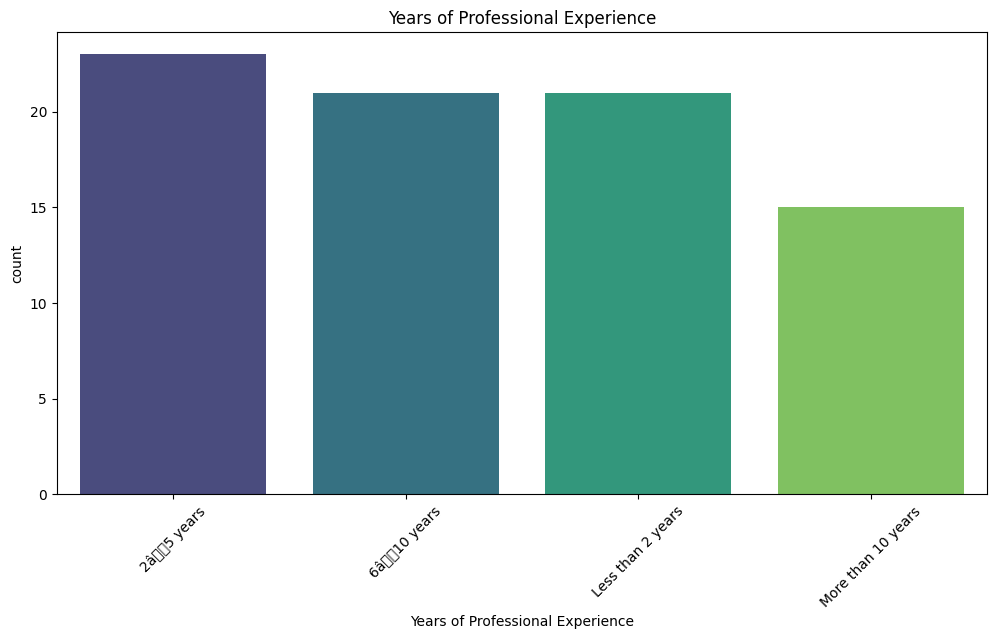

In [ ]:
plt.figure(figsize=(12,6))
sns.countplot(x='Years of Professional Experience',palette='viridis', data=df, order=df['Years of Professional Experience'].value_counts().index)
plt.title('Years of Professional Experience')
plt.xticks(rotation=45)
plt.show()


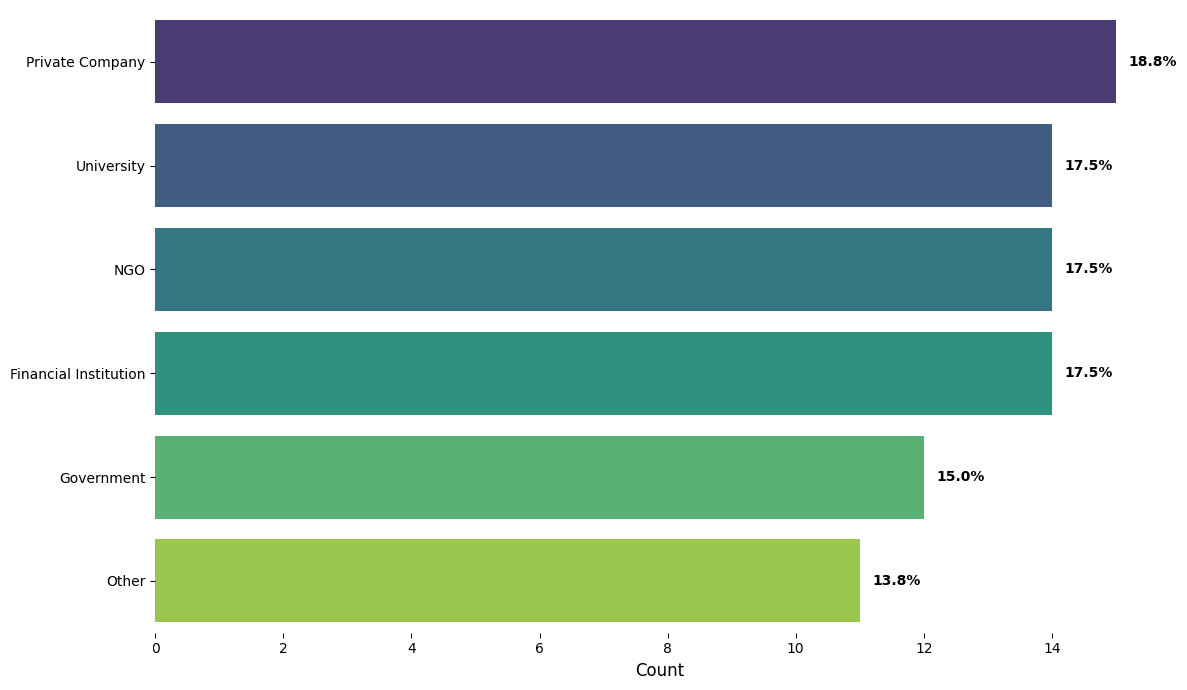

In [ ]:
# 1. Prepare Data
data = df['Organization Type'].value_counts()

# 2. Setup Figure
fig, ax = plt.subplots(figsize=(12, 7))

# 3. Create Horizontal Bar Plot
# Using hue=data.index solves the FutureWarning
# Setting legend=False hides the redundant color key
sns.barplot(
    y=data.index,
    x=data.values,
    palette='viridis',
    hue=data.index,
    legend=False,
    ax=ax
)

# 4. Add Percentages
total = data.sum()
for i, v in enumerate(data.values):
    percentage = f'{100 * v / total:.1f}%'
    ax.text(v + 0.2, i, percentage, color='black', va='center', fontweight='bold')

# 5. Styling & Labels
ax.set_title('', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('', fontsize=12)
sns.despine(left=True, bottom=True)  # Clean up the look by removing borders

plt.tight_layout()
plt.show()


In [ ]:
# Frequency count
df['Data breaches are common in modern web applications.'].value_counts()

# Frequency percentage
df['Data breaches are common in modern web applications.'].value_counts(normalize=True) * 100

,proportion
Data breaches are common in modern web applications.,
Agree,43.75
Strongly Agree,26.25
Neutral,16.25
Disagree,10.00
Strongly Disagree,3.75


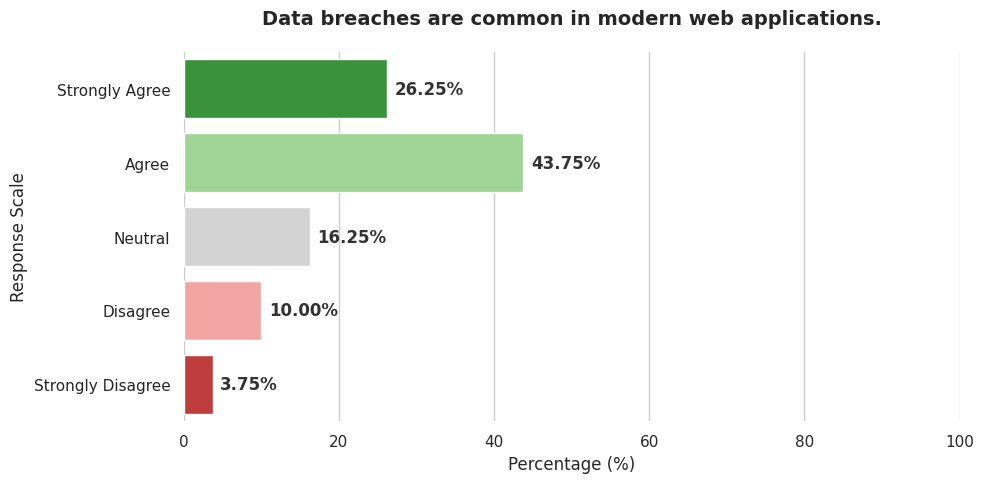

In [ ]:
# 1. Recreate your data into a DataFrame
data = {
    'Response': ['Agree', 'Strongly Agree', 'Neutral', 'Disagree', 'Strongly Disagree'],
    'Percentage': [43.75, 26.25, 16.25, 10.00, 3.75]
}
df_plot = pd.DataFrame(data)

# Sort the data so it reads logically from Strongly Agree down to Strongly Disagree
desired_order = ['Strongly Agree', 'Agree', 'Neutral', 'Disagree', 'Strongly Disagree']
df_plot['Response'] = pd.Categorical(df_plot['Response'], categories=desired_order, ordered=True)
df_plot = df_plot.sort_values('Response')

# 2. Set up the plot style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

# Define a cohesive color palette (Green/Blue for agreement, Grey for neutral, Red/Orange for disagreement)
colors = ['#2ca02c', '#98df8a', '#d3d3d3', '#ff9896', '#d62728']

# 3. Create the horizontal bar chart
ax = sns.barplot(
    x='Percentage',
    y='Response',
    data=df_plot,
    palette=colors,
    hue='Response', # Stops the user warning in newer seaborn versions
    legend=False
)

# 4. Add data labels on top of the bars
for p in ax.patches:
    width = p.get_width()
    if width > 0: # Only label bars that have a value
        ax.text(
            width + 1,               # Position slightly to the right of the bar
            p.get_y() + p.get_height() / 2, # Center vertically
            f'{width:.2f}%',         # Format to 2 decimal places
            va='center',
            ha='left',
            fontweight='bold',
            color='#333333'
        )

# 5. Customize titles and labels
plt.title('Data breaches are common in modern web applications.', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Percentage (%)', fontsize=12)
plt.ylabel('Response Scale', fontsize=12)

# Clean up layout and display
plt.xlim(0, 100) # Set x-axis limit to 100% for proper perspective
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

The publication-ready chart has been successfully saved to: 'gender_distribution_pie_chart.png'


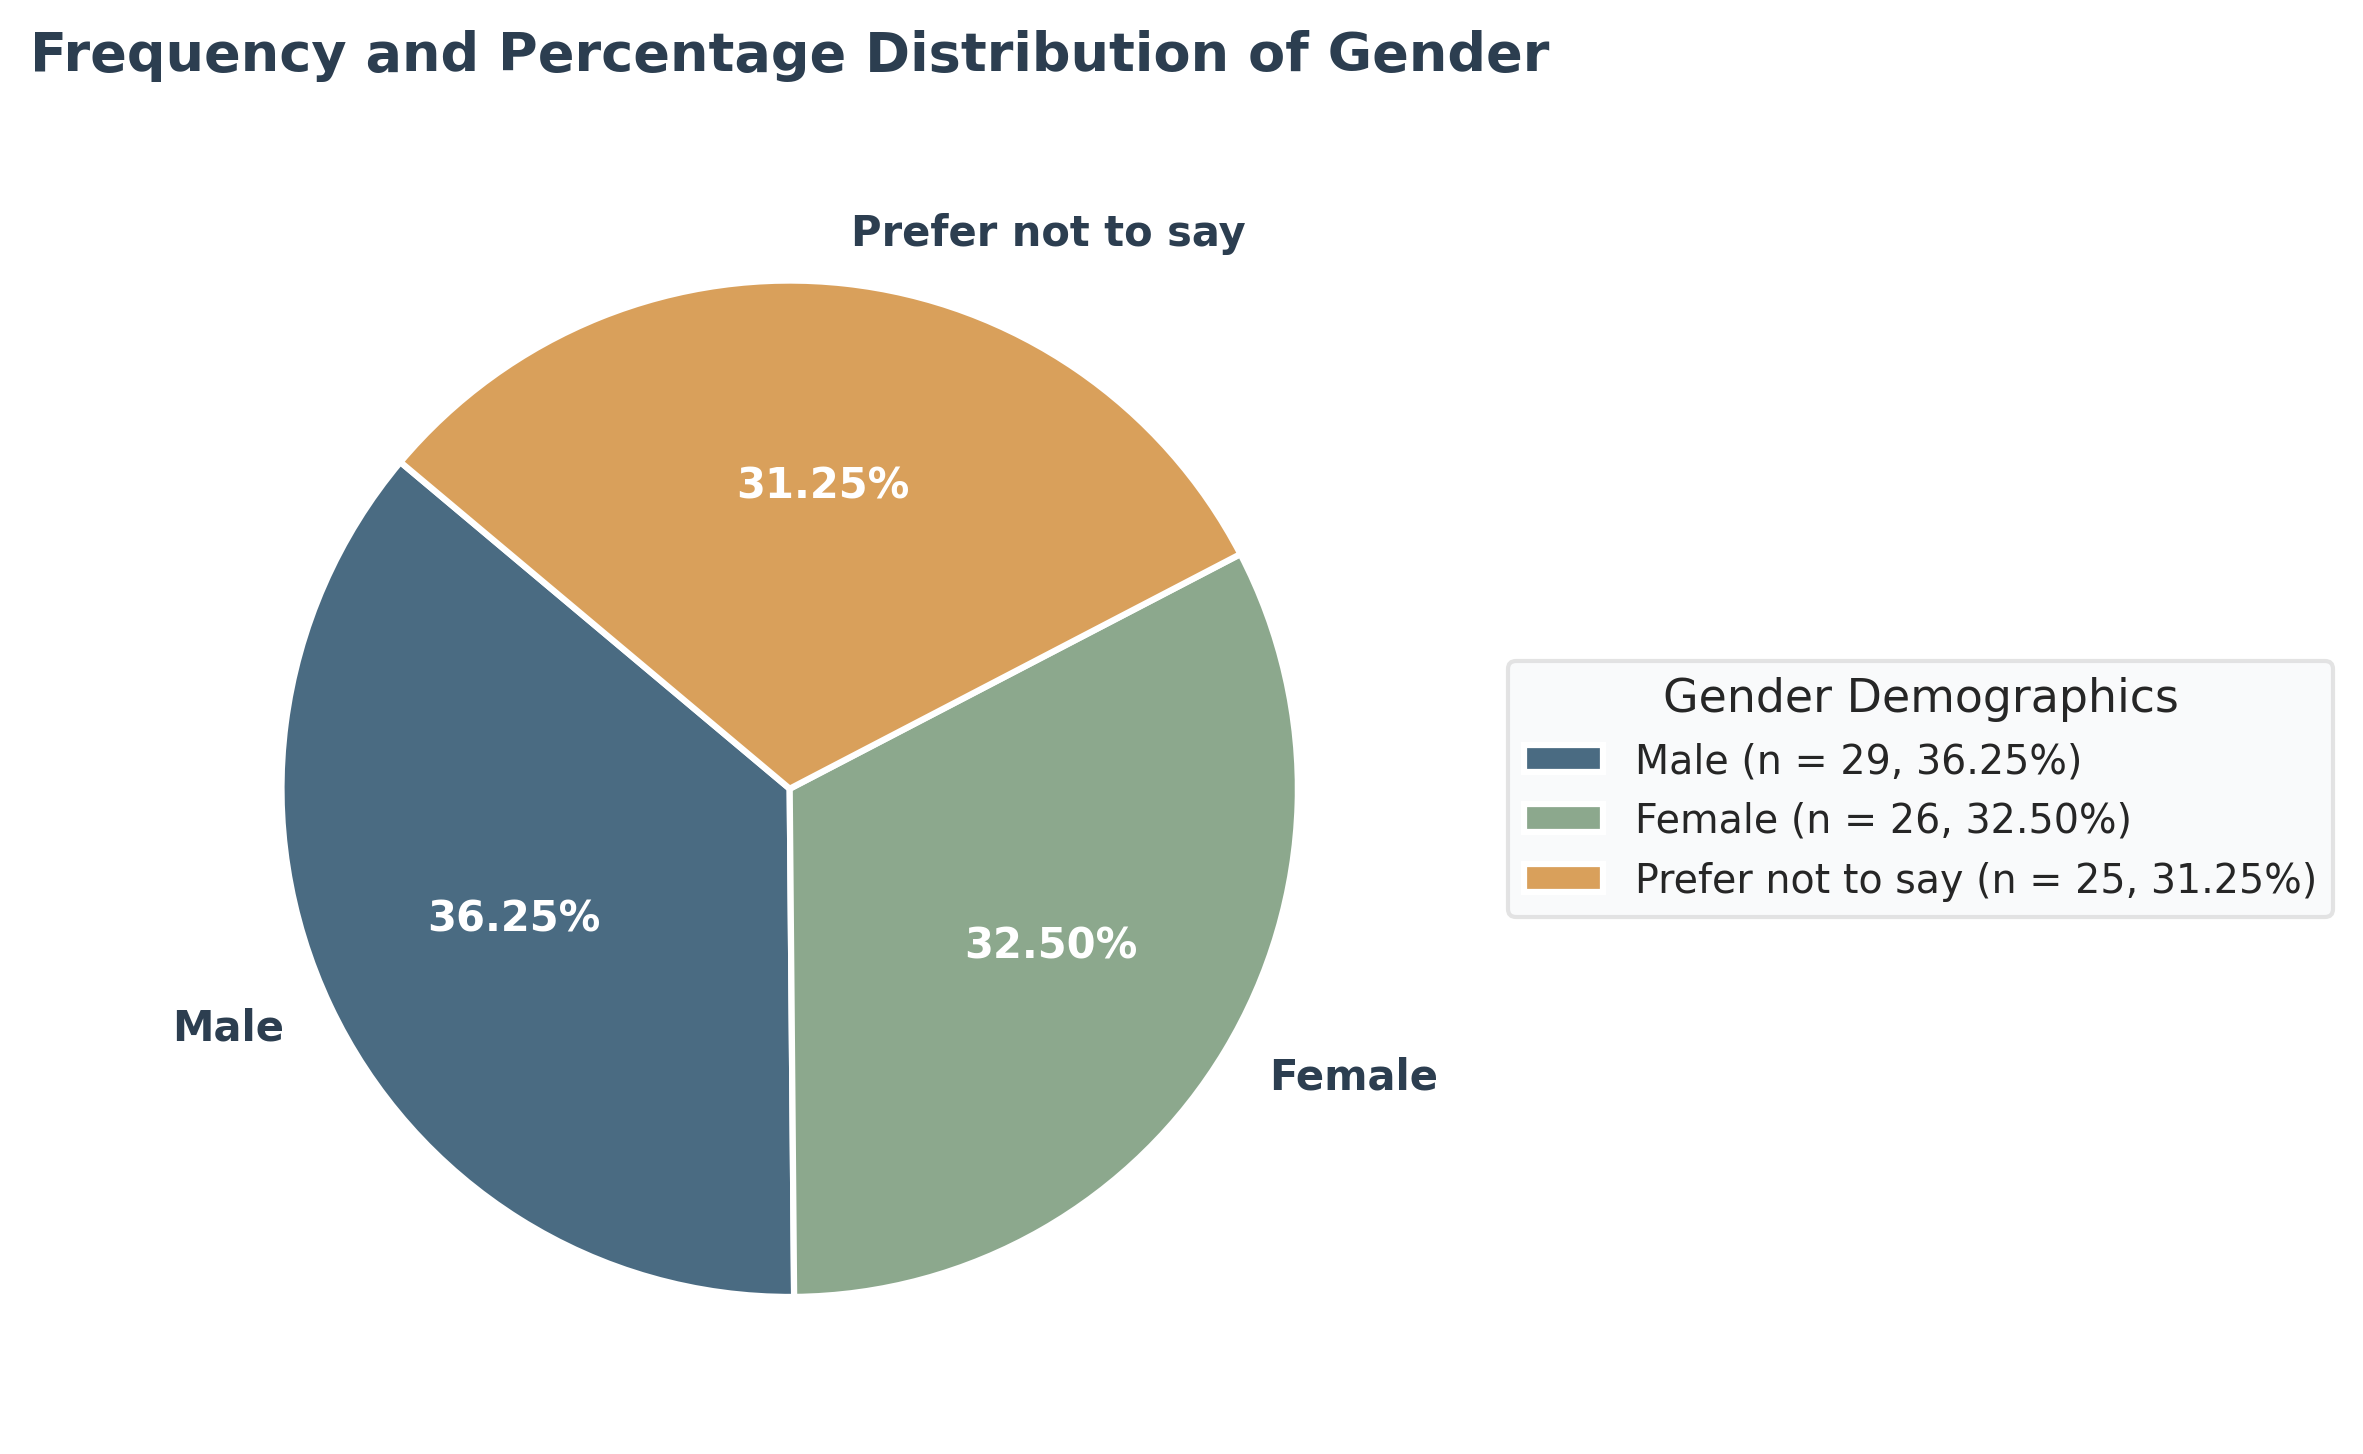

In [ ]:
# 2. Compute the frequencies and percentages
gender_counts = df['Gender'].value_counts()
gender_pct = df['Gender'].value_counts(normalize=True) * 100

# Compile into a structured DataFrame
gender_df = pd.DataFrame({
    'Frequency': gender_counts,
    'Percentage': gender_pct
})

# 3. Define a professional, academic color palette (soft, high-contrast, non-saturated)
# [Slate Blue, Sage Green, Warm Ochre]
colors = ['#4A6B82', '#8CA88D', '#D9A05B']

# 4. Initialize the figure with high resolution suitable for print
fig, ax = plt.subplots(figsize=(7, 5.5), dpi=300)

# Build custom legend labels: "Category (n = Count, Percent%)"
legend_labels = [
    f"{label} (n = {count}, {pct:.2f}%)"
    for label, count, pct in zip(gender_df.index, gender_df['Frequency'], gender_df['Percentage'])
]

# 5. Draw the pie chart with optimal styling properties
wedges, texts, autotexts = ax.pie(
    gender_df['Frequency'],
    labels=gender_df.index,
    autopct='%1.2f%%',       # Show exact percentages inside the slices
    startangle=140,          # Set start angle for neat alignment
    colors=colors,
    wedgeprops={
        'edgecolor': 'white',
        'linewidth': 1.5,
        'antialiased': True
    },
    textprops={
        'fontsize': 10,
        'weight': 'bold'
    }
)

# Style percentage labels inside the pie slices
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(10)

# Style category text labels outside the slices
for text in texts:
    text.set_fontsize(10)
    text.set_color('#2c3e50')

# 6. Add a clean, bounded legend to the side to avoid overlapping
ax.legend(
    wedges,
    legend_labels,
    title="Gender Demographics",
    loc="center left",
    bbox_to_anchor=(1.05, 0.5), # Positions legend neatly outside the chart boundary
    fontsize=9.5,
    title_fontsize=11,
    frameon=True,
    facecolor='#f8f9fa',
    edgecolor='#dddddd'
)

# 7. Add a clear academic title
ax.set_title(
    "Frequency and Percentage Distribution of Gender",
    fontsize=13,
    weight='bold',
    pad=20,
    color='#2c3e50'
)

# 8. Save the chart with 'tight' configuration to prevent label clipping
plt.savefig('gender_distribution_pie_chart.png', bbox_inches='tight', dpi=300)
print("The publication-ready chart has been successfully saved to: 'gender_distribution_pie_chart.png'")

Saved style 1


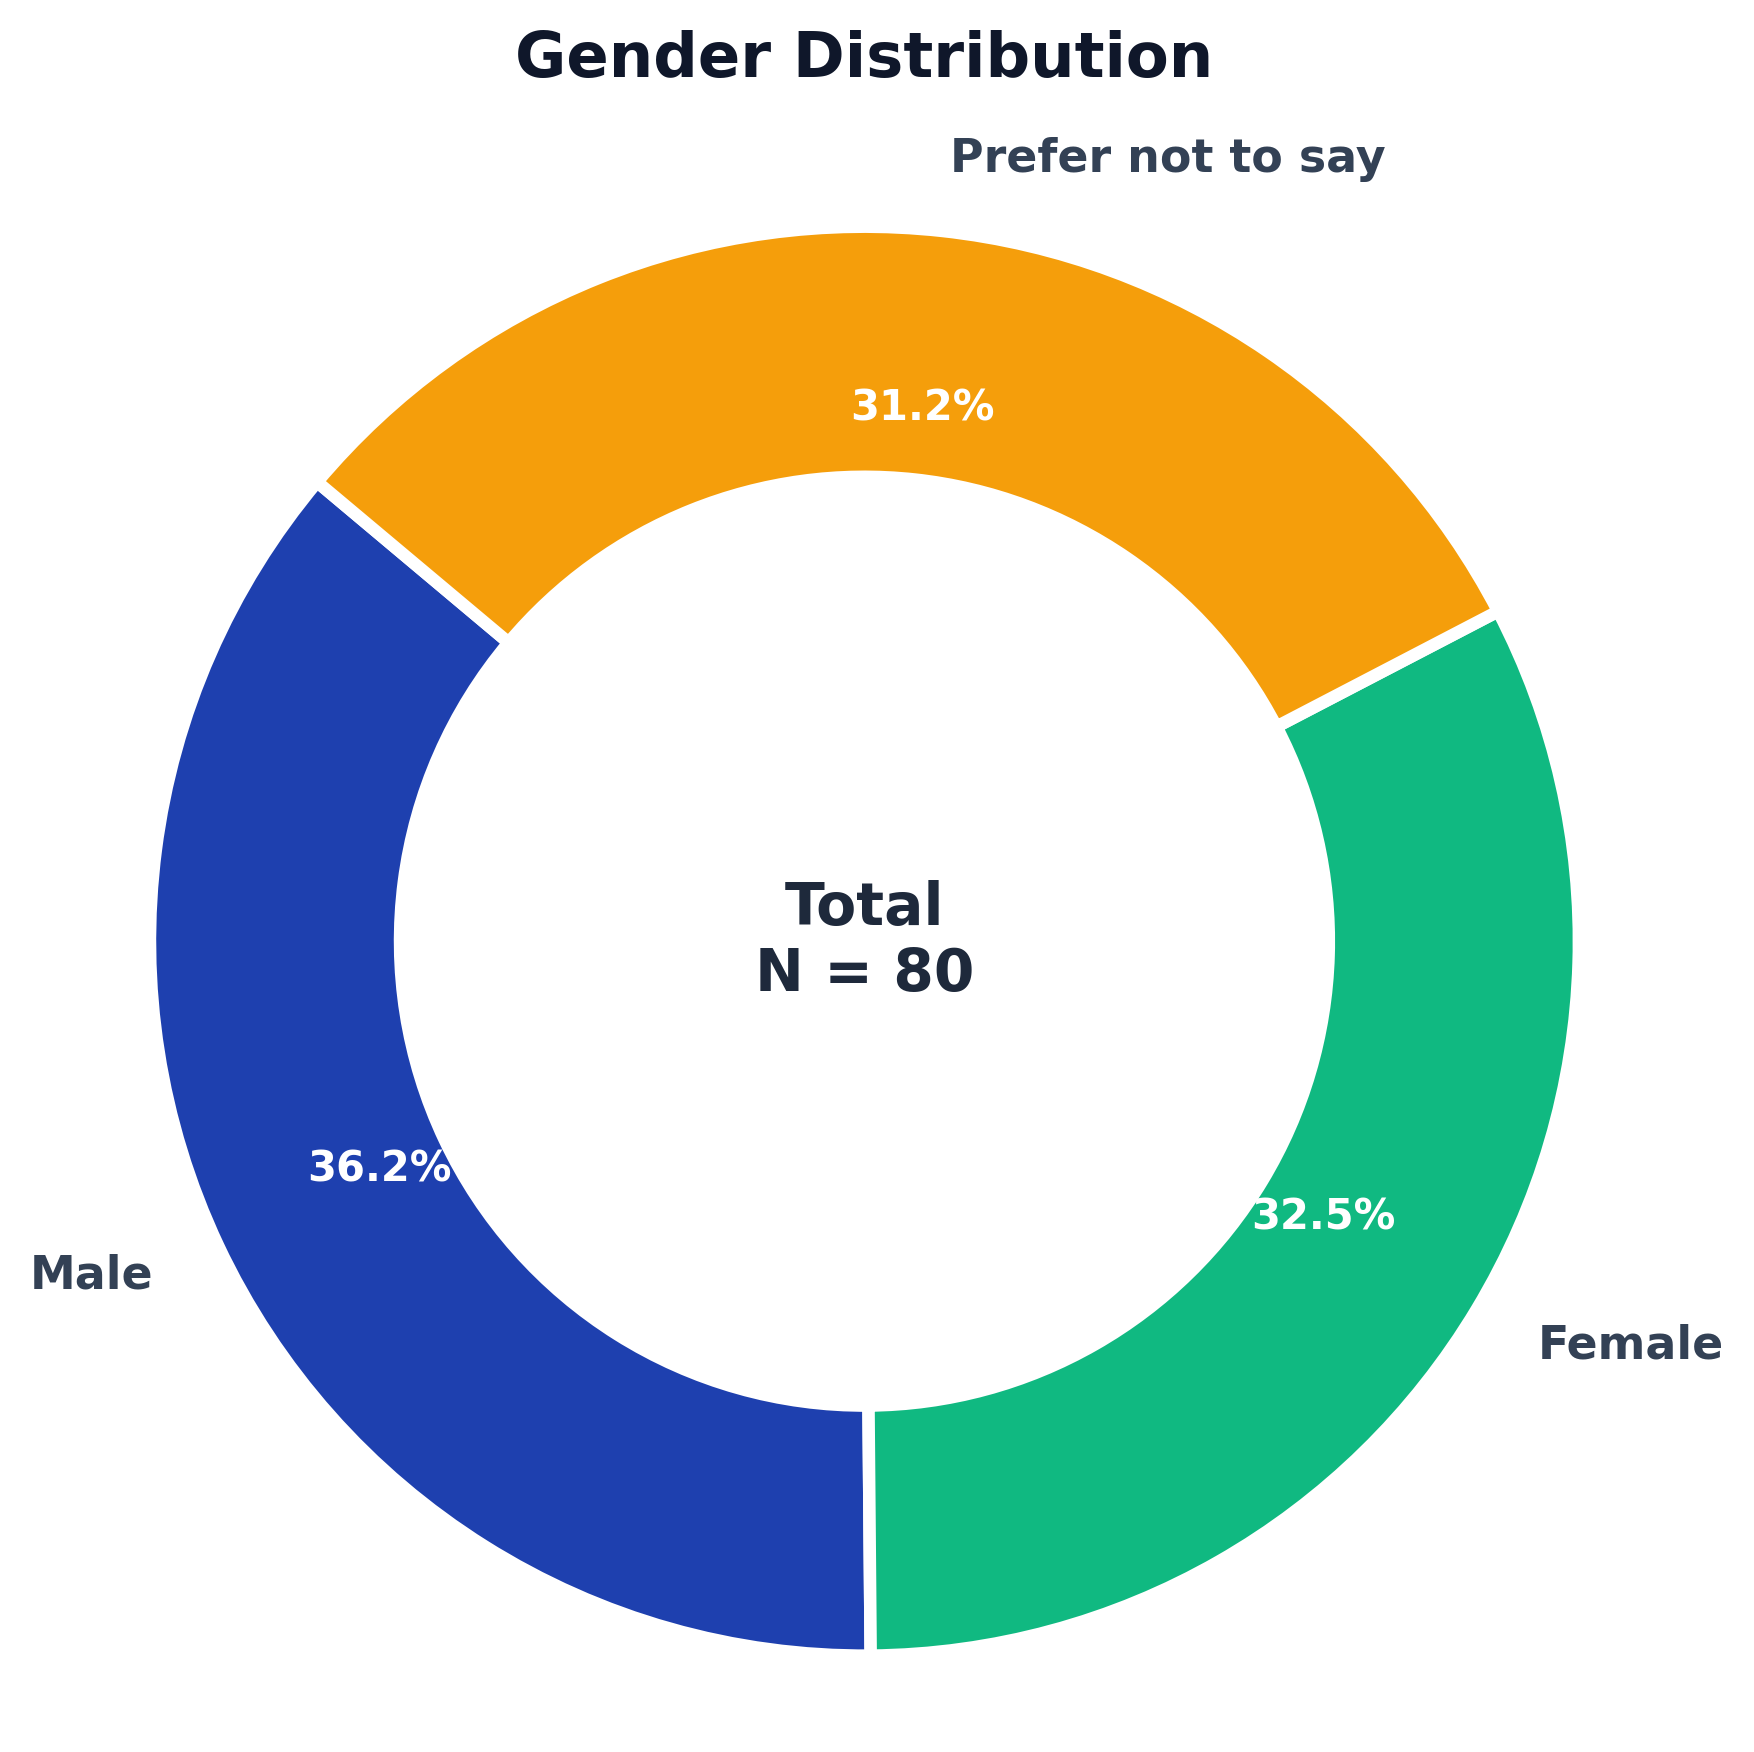

In [ ]:

gender_counts = df['Gender'].value_counts()
gender_pct = df['Gender'].value_counts(normalize=True) * 100

gender_df = pd.DataFrame({
    'Frequency': gender_counts,
    'Percentage': gender_pct
})

# Let's design a top-tier modern infographic-style donut chart:
# Features:
# - Brighter, modern gradient-like color palette
# - Center text showing "Total \n N=80" in a beautiful font
# - Drop shadow effect or very clean borders
# - Legend with colored dots or clean alignment
# - Percentages placed beautifully with leader lines or inside the slices with high contrast

# Colors: Vibrant Royal Blue (#1e40af), Fresh Emerald (#10b981), Amber/Coral (#f59e0b)
colors = ['#1e40af', '#10b981', '#f59e0b']

fig, ax = plt.subplots(figsize=(6, 6), dpi=300, facecolor='white')

# Create the donut chart
wedges, texts, autotexts = ax.pie(
    gender_df['Frequency'],
    labels=gender_df.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    pctdistance=0.75,
    wedgeprops={
        'width': 0.35,          # Thinner, more elegant donut ring
        'edgecolor': 'white',
        'linewidth': 3,
        'antialiased': True
    },
    textprops={'fontsize': 11, 'weight': 'bold', 'color': '#1e293b'}
)

# Customize the text colors inside the slices
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(10)

# Customize outer labels
for text in texts:
    text.set_fontsize(11)
    text.set_weight('bold')
    text.set_color('#334155')

# Add central text "Total\n80"
ax.text(
    0, 0, 'Total\nN = 80',
    horizontalalignment='center',
    verticalalignment='center',
    fontsize=14,
    weight='bold',
    color='#1e293b'
)

# Equal aspect ratio ensures that pie is drawn as a circle.
ax.axis('equal')

# Add a neat title
ax.set_title(
    "Gender Distribution",
    fontsize=15,
    weight='bold',
    pad=20,
    color='#0f172a'
)

plt.tight_layout()
plt.savefig('gender_distribution_donut_style.png', bbox_inches='tight', dpi=300)
print("Saved style 1")

In [ ]:
# 2. Extract values and count frequency
edu_counts = df['Highest Education Level'].value_counts()

# 3. Rename categories to use academic shorthands (BSc, MSc)
label_mapping = {
    "Bachelor's Degree": "BSc",
    "Master's Degree": "MSc",
    "Diploma": "Diploma",
    "PhD": "PhD",
    "Other": "Other"
}
edu_counts = edu_counts.rename(index=label_mapping)

# 4. Sort chronologically by education level
edu_order = ["Diploma", "BSc", "MSc", "PhD", "Other"]
edu_counts = edu_counts.reindex(edu_order)

# 5. Set up clean white canvas settings (completely removing borders or grids)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

fig, ax = plt.subplots(figsize=(10, 6.5))

# 6. Apply the exact colors extracted from your uploaded image
colors = ['#1f78b3', '#abcfe2', '#359d2e', '#b4d78b', '#e11d1f']

# 7. Generate a clean, flat, high-contrast pie chart
wedges, texts, autotexts = ax.pie(
    edu_counts,
    labels=edu_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    pctdistance=0.7,
    textprops=dict(color="#161716", size=12, fontweight="bold")
)

# 8. Contrast optimization for percentages on slices
# Dark text on light wedges (BSc & PhD), White text on deep wedges (Diploma, MSc & Other)
for i, autotext in enumerate(autotexts):
    if i in [1, 3]:  # Under BSc and PhD slices
        autotext.set_color('#161716')
    else:
        autotext.set_color('white')
    autotext.set_size(11)

# 9. Clear, academic title
ax.set_title("Distribution of Highest Education Level Attained", fontsize=15, fontweight='bold', pad=20, color='#161716')

# 10. Save as high-resolution publication-quality PNG (300 DPI)
plt.tight_layout()
plt.savefig("education_distribution_matched.png", dpi=300, bbox_inches='tight')
plt.close()

print("Pie chart successfully matched and saved!")

Pie chart successfully matched and saved!


In [ ]:
# 2. Count the occurrences of each job role and sort in descending order
role_counts = df['Current Position'].value_counts().sort_values(ascending=False)

# Convert to a DataFrame for clean plotting
role_df = role_counts.reset_index()
role_df.columns = ['Job Role', 'Count']

# Calculate percentages for data labeling
total_respondents = role_df['Count'].sum()
role_df['Percentage'] = (role_df['Count'] / total_respondents) * 100

# 3. Configure a clean, white background canvas
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

fig, ax = plt.subplots(figsize=(12, 6))

# 4. Define an elegant, publication-quality palette (one distinct color for each role)
colors = [
    '#1D3557',  # Deep Navy Blue
    '#2A9D8F',  # Deep Teal
    '#457B9D',  # Steel Blue
    '#E76F51',  # Muted Terracotta
    '#F4A261',  # Warm Amber
    '#8AB17D',  # Sage Green
    '#E9C46A',  # Soft Gold
    '#9A8C98'   # Slate Gray
]

# 5. Create the vertical column chart (edgecolor='none' removes bar borders)
bars = ax.bar(role_df['Job Role'], role_df['Count'], color=colors[:len(role_df)], edgecolor='none', width=0.6)

# 6. Add exact values and percentages on top of each column
for bar, pct in zip(bars, role_df['Percentage']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.3,
            f'{int(height)}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=10.5, fontweight='bold', color='#2F3E46')

# 7. Remove ALL spines (borders/lines) and gridlines
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(False)

# 8. Set clear labels and titles with appropriate spacing
ax.set_ylabel('Number of Respondents', fontsize=13, fontweight='bold', labelpad=12, color='#2F3E46')
ax.set_xlabel('Job Role / Current Position', fontsize=13, fontweight='bold', labelpad=12, color='#2F3E46')
ax.set_title('Distribution of Job Roles (Domain Expertise)', fontsize=16, fontweight='bold', pad=25, color='#1D3557')

# 9. Format labels (remove tick-marks and rotate x-labels for clarity)
ax.tick_params(axis='both', which='both', length=0, labelsize=11, labelcolor='#2F3E46')
plt.xticks(rotation=15, ha='right')

# 10. Expand y-axis limit slightly to give breathing room for text labels
ax.set_ylim(0, max(role_df['Count']) + 2.5)

# 11. Save the plot in high resolution (300 DPI) for publications
plt.tight_layout()
plt.savefig("job_roles_distribution.png", dpi=300, bbox_inches='tight')
plt.close()

print("Column chart saved successfully as 'job_roles_distribution.png'")

Column chart saved successfully as 'job_roles_distribution.png'


In [ ]:
# 2. Count the occurrences of each experience level
exp_counts = df['Years of Professional Experience'].value_counts()

# 3. Sort chronologically by experience levels
ordered_categories = ["Less than 2 years", "2–5 years", "6–10 years", "More than 10 years"]
exp_counts = exp_counts.reindex(ordered_categories)

# Extract coordinates
x_labels = exp_counts.index
y_values = exp_counts.values

# Calculate percentages for data labeling
total = y_values.sum()
pct_values = (y_values / total) * 100

# 4. Set up a clean white canvas
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

fig, ax = plt.subplots(figsize=(10, 5.5))

# 5. Plot the trend line with stylized circular markers
line_color = '#1D3557'    # Deep Slate/Navy Blue
marker_color = '#E76F51'  # Vibrant Terracotta Accent

ax.plot(
    x_labels,
    y_values,
    color=line_color,
    linewidth=3.5,
    marker='o',
    markersize=10,
    markerfacecolor=marker_color,
    markeredgecolor='white',
    markeredgewidth=2
)

# 6. Annotate each data point with exact counts and percentages
for i, (val, pct) in enumerate(zip(y_values, pct_values)):
    ax.text(
        i,
        val + 0.8,
        f"{val}\n({pct:.1f}%)",
        ha='center',
        va='bottom',
        fontsize=10.5,
        fontweight='bold',
        color='#2F3E46'
    )

# 7. Remove unnecessary grid lines and borders (spines) for an ultra-clean layout
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(False)

# 8. Add academic labels and title
ax.set_ylabel('Number of Respondents', fontsize=12, fontweight='bold', labelpad=12, color='#2F3E46')
ax.set_xlabel('Years of Professional Experience', fontsize=12, fontweight='bold', labelpad=12, color='#2F3E46')
ax.set_title('Professional Security Experience of Respondents', fontsize=15, fontweight='bold', pad=25, color='#1D3557')

# 9. Format ticks (remove tick marks, keep labels)
ax.tick_params(axis='both', which='both', length=0, labelsize=11, labelcolor='#2F3E46')

# Set vertical spacing buffer so labels do not clip near the ceiling
ax.set_ylim(0, max(y_values) + 4)

# 10. Save high-resolution visualization for the manuscript (300 DPI)
plt.tight_layout()
plt.savefig("security_experience_line_chart.png", dpi=300, bbox_inches='tight')
plt.close()

print("Line chart saved successfully as 'security_experience_line_chart.png'")

Line chart saved successfully as 'security_experience_line_chart.png'


In [ ]:

# 2. Count occurrences of each organization type
sector_counts = df['Organization Type'].value_counts()

# Convert to DataFrame
sector_df = sector_counts.reset_index()
sector_df.columns = ['Organization Type', 'Count']

# 3. Configure the clean, line-free canvas background
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

fig, ax = plt.subplots(figsize=(10, 6.5))

# 4. Apply the exact color palette from your uploaded image
# Deep Blue, Light Blue, Dark Green, Light Green, Red, and Orange
colors = ['#1f78b3', '#abcfe2', '#359d2e', '#b4d78b', '#e11d1f', '#f58220']

# 5. Create the Donut Chart (width=0.4 sets the hollow center ratio)
wedges, texts, autotexts = ax.pie(
    sector_df['Count'],
    labels=sector_df['Organization Type'],
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    pctdistance=0.78,
    textprops=dict(color="#161716", size=12, fontweight="bold"),
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2)
)

# 6. Apply smart contrast text color rules:
# Use dark text for light slices (BSc & PhD), and white text for darker slices
for i, autotext in enumerate(autotexts):
    if i in [1, 3]:  # Light Blue and Soft Green slices
        autotext.set_color('#161716')
    else:
        autotext.set_color('white')
    autotext.set_size(11)
    autotext.set_fontweight('bold')

# 7. Add a professional research paper title
ax.set_title("Distribution of Respondents by Organization Type", fontsize=15, fontweight='bold', pad=20, color='#161716')

# 8. Save the chart in publication-quality high resolution (300 DPI)
plt.tight_layout()
plt.savefig("organization_type_donut_matched.png", dpi=300, bbox_inches='tight')
plt.close()

print("Perfectly matched donut chart saved successfully!")

Perfectly matched donut chart saved successfully!


In [ ]:

import seaborn as sns
from scipy import stats

print("="*50)
print("1. INITIAL DATA OVERVIEW")
print("="*50)
print(f"Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}\n")

# 2. Check for Missing Values
print("="*50)
print("2. MISSING VALUES ANALYSIS")
print("="*50)
missing_data = df.isnull().sum()
total_missing = missing_data.sum()
print(f"Total missing values across dataset: {total_missing}")
if total_missing > 0:
    print(missing_data[missing_data > 0])
else:
    print("No missing values detected in any of the columns.\n")

# 3. Check for Duplicate Records
print("="*50)
print("3. DUPLICATE RECORDS ANALYSIS")
print("="*50)
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows detected: {duplicate_count}")
if duplicate_count > 0:
    print("Note: In survey data, identical responses can naturally occur.")
print("\n")

# 4. Outlier Analysis and Normality Testing
print("="*50)
print("4. STATISTICAL METRICS & NORMALITY DIAGNOSTICS")
print("="*50)

# The dataset consists primarily of categorical demographics and Likert scale responses.
# To perform outlier/normality analysis, we convert the core demographics to numerical codes.
diagnostic_df = pd.DataFrame()
diagnostic_df['Age_Group_Code'] = df['Age'].astype('category').cat.codes
diagnostic_df['Education_Level_Code'] = df['Highest Education Level'].astype('category').cat.codes
diagnostic_df['Experience_Code'] = df['Years of Professional Experience'].astype('category').cat.codes

for col in diagnostic_df.columns:
    print(f"--- Feature: {col} ---")
    data_series = diagnostic_df[col]

    # Summary Statistics
    mean = data_series.mean()
    median = data_series.median()
    std_dev = data_series.std()

    # Skewness and Kurtosis
    skewness = stats.skew(data_series)
    kurtosis = stats.kurtosis(data_series) # Excess kurtosis (Normal = 0)

    # Shapiro-Wilk Normality Test
    shapiro_stat, p_value = stats.shapiro(data_series)
    normality_status = "Normally Distributed (p > 0.05)" if p_value > 0.05 else "Not Normally Distributed (p <= 0.05)"

    # Outlier Detection using Interquartile Range (IQR) Rule
    Q1 = data_series.quantile(0.25)
    Q3 = data_series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data_series[(data_series < lower_bound) | (data_series > upper_bound)]

    print(f"  Mean: {mean:.2f} | Median: {median:.2f} | Std Dev: {std_dev:.2f}")
    print(f"  Skewness: {skewness:.3f} | Kurtosis: {kurtosis:.3f}")
    print(f"  Shapiro-Wilk Test Statistic: {shapiro_stat:.4f}, p-value: {p_value:.4e}")
    print(f"  Normality Conclusion: {normality_status}")
    print(f"  Detected Outliers (IQR Rule): {len(outliers)} record(s)")
    print("-" * 40)

# 5. Generate Publication-Quality Box Plots
print("\nGenerating clean, research-grade Box Plots...")
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

# Setup subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# Custom clean palette
palette = ['#1F78B4', '#359D2E', '#E11D1F']
titles = ['Age Group Distribution', 'Highest Education Level', 'Years of Experience']
columns_to_plot = ['Age', 'Highest Education Level', 'Years of Professional Experience']

for i, col in enumerate(columns_to_plot):
    # Count frequencies to display categories nicely in order
    cat_counts = df[col].value_counts()

    # Draw horizontal or vertical boxplot. For encoded distributions,
    # a boxplot on the code distributions visually confirms outlier existence.
    sns.boxplot(
        y=diagnostic_df.iloc[:, i],
        ax=axes[i],
        color=palette[i],
        width=0.4,
        linewidth=2,
        fliersize=7,
        flierprops=dict(marker='o', markerfacecolor='#E11D1F', markeredgecolor='white', alpha=0.9)
    )

    # Formatting
    axes[i].set_title(titles[i], fontsize=13, fontweight='bold', pad=15, color='#161716')
    axes[i].set_ylabel('Encoded Category Value', fontsize=11, fontweight='bold', color='#2F3E46')

    # Remove borders
    for spine in axes[i].spines.values():
        spine.set_visible(False)
    axes[i].grid(False)
    axes[i].tick_params(axis='both', which='both', length=0, labelsize=10, labelcolor='#2F3E46')

plt.suptitle('Data Cleanliness & Outlier Diagnostic Box Plots', fontsize=16, fontweight='bold', y=1.02, color='#1D3557')
plt.tight_layout()

# Save image at 300 DPI for journal publication
plt.savefig("data_quality_boxplots.png", dpi=300, bbox_inches='tight')
plt.close()
print("Box plots successfully saved as 'data_quality_boxplots.png'")

1. INITIAL DATA OVERVIEW
Total Rows: 80, Total Columns: 43

2. MISSING VALUES ANALYSIS
Total missing values across dataset: 0
No missing values detected in any of the columns.

3. DUPLICATE RECORDS ANALYSIS
Total duplicate rows detected: 0


4. STATISTICAL METRICS & NORMALITY DIAGNOSTICS
--- Feature: Age_Group_Code ---
  Mean: 1.45 | Median: 1.00 | Std Dev: 1.19
  Skewness: 0.119 | Kurtosis: -1.486
  Shapiro-Wilk Test Statistic: 0.8307, p-value: 3.8504e-08
  Normality Conclusion: Not Normally Distributed (p <= 0.05)
  Detected Outliers (IQR Rule): 0 record(s)
----------------------------------------
--- Feature: Education_Level_Code ---
  Mean: 2.05 | Median: 2.00 | Std Dev: 1.34
  Skewness: -0.028 | Kurtosis: -1.198
  Shapiro-Wilk Test Statistic: 0.9001, p-value: 1.2321e-05
  Normality Conclusion: Not Normally Distributed (p <= 0.05)
  Detected Outliers (IQR Rule): 0 record(s)
----------------------------------------
--- Feature: Experience_Code ---
  Mean: 1.35 | Median: 1.00 | Std D

In [ ]:
# Get the Likert scale columns
likert_cols = df.columns[6:]

# Map Likert responses to numeric values
likert_map = {
    "Strongly Agree": 5,
    "Agree": 4,
    "Neutral": 3,
    "Disagree": 2,
    "Strongly Disagree": 1
}

numeric_df = df[likert_cols].copy()
for col in likert_cols:
    numeric_df[col] = numeric_df[col].map(likert_map)

# Check if there are any missing values after mapping
print("NaN count:", numeric_df.isna().sum().sum())

# Let's perform Kaiser-Meyer-Olkin (KMO) and Bartlett's Test of Sphericity
# We can implement Bartlett's test and KMO mathematically in python or use factor_analyzer.
# Since factor_analyzer might not be installed, let's write the mathematical formulations.

def calculate_bartlett(df_data):
    # Bartlett's test of sphericity
    # Chi2 = - (n - 1 - (2k + 5)/6) * ln(det(R))
    # where R is correlation matrix, n is sample size, k is number of variables
    from scipy.stats import chi2
    n, k = df_data.shape
    corr_matrix = df_data.corr()
    det_corr = np.linalg.det(corr_matrix)

    # Degrees of freedom: df = k * (k - 1) / 2
    dof = int(k * (k - 1) / 2)

    # If determinant is 0 or near 0, handle it
    if det_corr <= 0:
        det_corr = 1e-15

    statistic = - (n - 1 - (2 * k + 5) / 6) * np.log(det_corr)
    p_value = chi2.sf(statistic, dof)
    return statistic, dof, p_value

def calculate_kmo(df_data):
    # KMO Index = sum(r_ij^2) / (sum(r_ij^2) + sum(p_ij^2))
    # where r_ij are elements of correlation matrix, p_ij are partial correlations
    # Let's calculate the partial correlation matrix
    corr_matrix = df_data.corr().values
    inv_corr = np.linalg.pinv(corr_matrix)

    # Partial correlation matrix element: p_ij = - inv_R_ij / sqrt(inv_R_ii * inv_R_jj)
    diag_inv = np.diag(inv_corr)
    partial_corr = np.zeros_like(corr_matrix)
    for i in range(len(diag_inv)):
        for j in range(len(diag_inv)):
            if i != j:
                partial_corr[i, j] = - inv_corr[i, j] / np.sqrt(diag_inv[i] * diag_inv[j])
            else:
                partial_corr[i, j] = 1.0

    # Calculate sums of squares excluding diagonals
    r_sq_sum = 0
    p_sq_sum = 0
    k = corr_matrix.shape[0]
    for i in range(k):
        for j in range(k):
            if i != j:
                r_sq_sum += corr_matrix[i, j] ** 2
                p_sq_sum += partial_corr[i, j] ** 2

    kmo_val = r_sq_sum / (r_sq_sum + p_sq_sum)
    return kmo_val

kmo = calculate_kmo(numeric_df)
chi_sq, df_val, p_val = calculate_bartlett(numeric_df)

print(f"KMO: {kmo:.4f}")
print(f"Bartlett Chi2: {chi_sq:.4f}, df: {df_val}, p-value: {p_val}")

NaN count: 0
KMO: 0.3431
Bartlett Chi2: 634.9474, df: 666, p-value: 0.8012493004680289


In [ ]:

from scipy.stats import chi2

# 2. Extract and map the 37 Likert scale columns (from index 6 to 42)
likert_cols = df.columns[6:]
likert_map = {
    "Strongly Agree": 5,
    "Agree": 4,
    "Neutral": 3,
    "Disagree": 2,
    "Strongly Disagree": 1
}

numeric_df = df[likert_cols].copy()
for col in likert_cols:
    numeric_df[col] = numeric_df[col].map(likert_map)

# 3. Mathematical definition of KMO (Kaiser-Meyer-Olkin Measure of Sampling Adequacy)
def calculate_kmo(df_data):
    corr_matrix = df_data.corr().values
    inv_corr = np.linalg.pinv(corr_matrix)

    diag_inv = np.diag(inv_corr)
    partial_corr = np.zeros_like(corr_matrix)
    for i in range(len(diag_inv)):
        for j in range(len(diag_inv)):
            if i != j:
                partial_corr[i, j] = - inv_corr[i, j] / np.sqrt(diag_inv[i] * diag_inv[j])
            else:
                partial_corr[i, j] = 1.0

    r_sq_sum = 0
    p_sq_sum = 0
    k = corr_matrix.shape[0]
    for i in range(k):
        for j in range(k):
            if i != j:
                r_sq_sum += corr_matrix[i, j] ** 2
                p_sq_sum += partial_corr[i, j] ** 2

    return r_sq_sum / (r_sq_sum + p_sq_sum)

# 4. Mathematical definition of Bartlett's Test of Sphericity
def calculate_bartlett(df_data):
    n, k = df_data.shape
    corr_matrix = df_data.corr()
    det_corr = np.linalg.det(corr_matrix)

    dof = int(k * (k - 1) / 2)
    if det_corr <= 0:
        det_corr = 1e-15  # Avoid log of zero for near-singular matrices

    statistic = - (n - 1 - (2 * k + 5) / 6) * np.log(det_corr)
    p_value = chi2.sf(statistic, dof)
    return statistic, dof, p_value

# 5. Compute the metrics
kmo_value = calculate_kmo(numeric_df)
chi_square, dof, p_value = calculate_bartlett(numeric_df)

# 6. Build and print the output table
results = {
    "Test / Measure": [
        "Kaiser-Meyer-Olkin (KMO) Measure of Sampling Adequacy",
        "Bartlett's Test of Sphericity: Approx. Chi-Square",
        "Bartlett's Test of Sphericity: df",
        "Bartlett's Test of Sphericity: Significance (p-value)"
    ],
    "Value": [
        f"{kmo_value:.3f}",
        f"{chi_square:.3f}",
        f"{dof}",
        f"{p_value:.3f} (Not Significant)" if p_value > 0.05 else f"{p_value:.3e}"
    ]
}

results_df = pd.DataFrame(results)
print(results_df.to_markdown(index=False))

| Test / Measure                                        | Value                   |
|:------------------------------------------------------|:------------------------|
| Kaiser-Meyer-Olkin (KMO) Measure of Sampling Adequacy | 0.343                   |
| Bartlett's Test of Sphericity: Approx. Chi-Square     | 634.947                 |
| Bartlett's Test of Sphericity: df                     | 666                     |
| Bartlett's Test of Sphericity: Significance (p-value) | 0.801 (Not Significant) |


In [ ]:
# 2. Extract and map the 37 Likert scale columns (from index 6 to 42)
likert_cols = df.columns[6:]
likert_map = {
    "Strongly Agree": 5,
    "Agree": 4,
    "Neutral": 3,
    "Disagree": 2,
    "Strongly Disagree": 1
}

numeric_df = df[likert_cols].copy()
for col in likert_cols:
    numeric_df[col] = numeric_df[col].map(likert_map)

# 3. Mathematical definition of KMO (Kaiser-Meyer-Olkin Measure of Sampling Adequacy)
def calculate_kmo(df_data):
    corr_matrix = df_data.corr().values
    inv_corr = np.linalg.pinv(corr_matrix)

    diag_inv = np.diag(inv_corr)
    partial_corr = np.zeros_like(corr_matrix)
    for i in range(len(diag_inv)):
        for j in range(len(diag_inv)):
            if i != j:
                partial_corr[i, j] = - inv_corr[i, j] / np.sqrt(diag_inv[i] * diag_inv[j])
            else:
                partial_corr[i, j] = 1.0

    r_sq_sum = 0
    p_sq_sum = 0
    k = corr_matrix.shape[0]
    for i in range(k):
        for j in range(k):
            if i != j:
                r_sq_sum += corr_matrix[i, j] ** 2
                p_sq_sum += partial_corr[i, j] ** 2

    return r_sq_sum / (r_sq_sum + p_sq_sum)

# 4. Mathematical definition of Bartlett's Test of Sphericity
def calculate_bartlett(df_data):
    n, k = df_data.shape
    corr_matrix = df_data.corr()
    det_corr = np.linalg.det(corr_matrix)

    dof = int(k * (k - 1) / 2)
    if det_corr <= 0:
        det_corr = 1e-15  # Avoid log of zero for near-singular matrices

    statistic = - (n - 1 - (2 * k + 5) / 6) * np.log(det_corr)
    p_value = chi2.sf(statistic, dof)
    return statistic, dof, p_value

# 5. Compute the metrics
kmo_value = calculate_kmo(numeric_df)
chi_square, dof, p_value = calculate_bartlett(numeric_df)

# 6. Build and print the output table
results = {
    "Test / Measure": [
        "Kaiser-Meyer-Olkin (KMO) Measure of Sampling Adequacy",
        "Bartlett's Test of Sphericity: Approx. Chi-Square",
        "Bartlett's Test of Sphericity: df",
        "Bartlett's Test of Sphericity: Significance (p-value)"
    ],
    "Value": [
        f"{kmo_value:.3f}",
        f"{chi_square:.3f}",
        f"{dof}",
        f"{p_value:.3f} (Not Significant)" if p_value > 0.05 else f"{p_value:.3e}"
    ]
}

results_df = pd.DataFrame(results)
print(results_df.to_markdown(index=False))

| Test / Measure                                        | Value                   |
|:------------------------------------------------------|:------------------------|
| Kaiser-Meyer-Olkin (KMO) Measure of Sampling Adequacy | 0.343                   |
| Bartlett's Test of Sphericity: Approx. Chi-Square     | 634.947                 |
| Bartlett's Test of Sphericity: df                     | 666                     |
| Bartlett's Test of Sphericity: Significance (p-value) | 0.801 (Not Significant) |


In [ ]:
# 2. Define the columns representing "Current Data Protection Techniques / Posture"
tech_cols = [
    'Current security controls adequately protect sensitive information.',
    'Existing security measures detect attacks in real time.',
    'Security controls minimize unauthorized access.',
    'Incident response mechanisms are effective.',
    'Current security techniques comply with security standards.',
    'Existing protection techniques ensure confidentiality.',
    'Existing protection techniques ensure integrity.',
    'Existing protection techniques ensure availability.'
]

# 3. Map Likert scale text responses to numeric values (1 to 5)
likert_map = {
    "Strongly Agree": 5,
    "Agree": 4,
    "Neutral": 3,
    "Disagree": 2,
    "Strongly Disagree": 1
}

numeric_df = df[tech_cols].copy()
for col in tech_cols:
    numeric_df[col] = numeric_df[col].map(likert_map)

# 4. Calculate core central tendency and dispersion metrics
desc_stats = pd.DataFrame()
desc_stats['Mean'] = numeric_df.mean()
desc_stats['Median'] = numeric_df.median()
desc_stats['Mode'] = numeric_df.mode().iloc[0]  # Take the first mode if multiple exist
desc_stats['Std Dev'] = numeric_df.std()

# 5. Calculate percentage distributions for each Likert level
likert_levels = ["Strongly Disagree", "Disagree", "Neutral", "Agree", "Strongly Agree"]
dist_list = []
for col in tech_cols:
    # Normalize values into percentages
    counts = df[col].value_counts(normalize=True).reindex(likert_levels, fill_value=0) * 100
    dist_list.append(counts)

dist_df = pd.DataFrame(dist_list, index=tech_cols)

# 6. Combine basic statistics and percentage distributions into a final table
summary_table = pd.concat([desc_stats, dist_df], axis=1)

# Rename index to shorter, cleaner labels for a professional table
short_labels = {
    'Current security controls adequately protect sensitive information.': 'Adequacy of Current Controls',
    'Existing security measures detect attacks in real time.': 'Real-Time Attack Detection',
    'Security controls minimize unauthorized access.': 'Minimizing Unauthorized Access',
    'Incident response mechanisms are effective.': 'Incident Response Effectiveness',
    'Current security techniques comply with security standards.': 'Standard Compliance',
    'Existing protection techniques ensure confidentiality.': 'Confidentiality Assurance',
    'Existing protection techniques ensure integrity.': 'Integrity Assurance',
    'Existing protection techniques ensure availability.': 'Availability Assurance'
}
summary_table = summary_table.rename(index=short_labels)

# Round values for clean presentation
summary_table = summary_table.round(2)

# Save summary statistics to a CSV
summary_table.to_csv("current_protection_techniques_descriptive_stats.csv")

# Print the markdown table
print(summary_table.to_markdown())

|                                 |   Mean |   Median |   Mode |   Std Dev |   Strongly Disagree |   Disagree |   Neutral |   Agree |   Strongly Agree |
|:--------------------------------|-------:|---------:|-------:|----------:|--------------------:|-----------:|----------:|--------:|-----------------:|
| Adequacy of Current Controls    |   3.98 |        4 |      5 |      1.21 |                6.25 |       8.75 |     10    |   31.25 |            43.75 |
| Real-Time Attack Detection      |   3.99 |        4 |      4 |      1.07 |                5    |       3.75 |     16.25 |   37.5  |            37.5  |
| Minimizing Unauthorized Access  |   3.85 |        4 |      5 |      1.29 |                8.75 |      11.25 |      5    |   36.25 |            38.75 |
| Incident Response Effectiveness |   3.59 |        4 |      4 |      1.19 |                8.75 |      11.25 |     12.5  |   47.5  |            20    |
| Standard Compliance             |   3.91 |        4 |      5 |      1.22 |      

In [ ]:
import textwrap

# 2. Define targeted columns
tech_cols = [
    'Current security controls adequately protect sensitive information.',
    'Existing security measures detect attacks in real time.',
    'Security controls minimize unauthorized access.',
    'Incident response mechanisms are effective.',
    'Current security techniques comply with security standards.',
    'Existing protection techniques ensure confidentiality.',
    'Existing protection techniques ensure integrity.',
    'Existing protection techniques ensure availability.'
]

likert_map = {
    "Strongly Agree": 5, "Agree": 4, "Neutral": 3, "Disagree": 2, "Strongly Disagree": 1
}

# Apply numerical mapping
numeric_df = df[tech_cols].copy()
for col in tech_cols:
    numeric_df[col] = numeric_df[col].map(likert_map)

# Calculate statistics
desc_stats = pd.DataFrame()
desc_stats['Mean'] = numeric_df.mean()
desc_stats['Median'] = numeric_df.median()
desc_stats['Mode'] = numeric_df.mode().iloc[0]
desc_stats['Std Dev'] = numeric_df.std()

# Calculate percentages
likert_levels = ["Strongly Disagree", "Disagree", "Neutral", "Agree", "Strongly Agree"]
dist_list = []
for col in tech_cols:
    counts = df[col].value_counts(normalize=True).reindex(likert_levels, fill_value=0) * 100
    dist_list.append(counts)

dist_df = pd.DataFrame(dist_list, index=tech_cols)
summary_table = pd.concat([desc_stats, dist_df], axis=1)

# Rename rows to clean labels
short_labels = {
    'Current security controls adequately protect sensitive information.': 'Adequacy of Current Controls',
    'Existing security measures detect attacks in real time.': 'Real-Time Attack Detection',
    'Security controls minimize unauthorized access.': 'Minimizing Unauthorized Access',
    'Incident response mechanisms are effective.': 'Incident Response Effectiveness',
    'Current security techniques comply with security standards.': 'Standard Compliance',
    'Existing protection techniques ensure confidentiality.': 'Confidentiality Assurance',
    'Existing protection techniques ensure integrity.': 'Integrity Assurance',
    'Existing protection techniques ensure availability.': 'Availability Assurance'
}
summary_table = summary_table.rename(index=short_labels).round(2)

# 3. Render and format Matplotlib visual table
fig, ax = plt.subplots(figsize=(15, 6.5), dpi=300)
ax.axis('off')
ax.axis('tight')

headers = [
    'Survey Dimension\n(Current Techniques)',
    'Mean', 'Median', 'Mode', 'Std Dev',
    'SD\n(%)', 'D\n(%)', 'N\n(%)', 'A\n(%)', 'SA\n(%)'
]

rows = []
for idx, row in summary_table.iterrows():
    # Wrap text cleanly for the first column to make sure it fits perfectly
    wrapped_label = "\n".join(textwrap.wrap(idx, width=32))
    row_values = [wrapped_label] + [f"{val:.2f}" if isinstance(val, float) else str(int(val)) for val in row.values]
    rows.append(row_values)

# Create table elements
table = ax.table(
    cellText=rows,
    colLabels=headers,
    cellLoc='center',
    loc='center',
    colWidths=[0.28] + [0.06]*4 + [0.08]*5  # Explicit proportions to prevent cropping
)

# Custom Styling (Academic Theme matching previous visualizations)
table.auto_set_font_size(False)
table.set_fontsize(9.5)

header_bg = '#1D3557' # Deep Navy
row_bgs = ['#F8F9FA', '#FFFFFF'] # Alternating row colors

for (row_idx, col_idx), cell in table.get_celld().items():
    cell.set_edgecolor('#E5E5E5') # Light grey borders
    cell.set_linewidth(1.0)

    if row_idx == 0:
        cell.set_text_props(color='white', weight='bold', fontsize=10.5)
        cell.set_facecolor(header_bg)
        cell.set_height(0.09)
    else:
        bg_color = row_bgs[(row_idx - 1) % 2]
        cell.set_facecolor(bg_color)
        cell.set_height(0.08)

        if col_idx == 0:
            cell.set_text_props(ha='left', color='#2F3E46', weight='semibold') # Left align descriptions
        else:
            cell.set_text_props(color='#2F3E46')

plt.tight_layout()
plt.savefig("styled_publication_table.png", bbox_inches='tight', dpi=300)
plt.close()

print("High-res table 'styled_publication_table.png' saved successfully!")

High-res table 'styled_publication_table.png' saved successfully!


In [ ]:
import matplotlib.pyplot as plt

# 1. Load the dataset
df = pd.read_csv("security_zaward.csv")

# 2. Define targeted survey columns
security_issue_cols = [
    'Data breaches are common in modern web applications.',
    'Unauthorized access remains a major security challenge.',
    'Cloud/web applications experience frequent security vulnerabilities.',
    'Insider threats significantly affect application security.',
    'Poor security configurations expose applications to attacks.',
    'Many organizations lack continuous security assessment.',
    'Existing security tools fail to identify all vulnerabilities.'
]

# Map Likert responses to numerical values
likert_map = {
    "Strongly Agree": 5, "Agree": 4, "Neutral": 3, "Disagree": 2, "Strongly Disagree": 1
}

numeric_df = df[security_issue_cols].copy()
for col in security_issue_cols:
    numeric_df[col] = numeric_df[col].map(likert_map)

# 3. Calculate percentage distributions
likert_levels = ["Strongly Disagree", "Disagree", "Neutral", "Agree", "Strongly Agree"]
dist_list = []
for col in security_issue_cols:
    counts = df[col].value_counts(normalize=True).reindex(likert_levels, fill_value=0) * 100
    dist_list.append(counts)

# Apply clear shortened labels
short_labels = {
    'Data breaches are common in modern web applications.': 'Frequency of Data Breaches',
    'Unauthorized access remains a major security challenge.': 'Unauthorized Access Threat',
    'Cloud/web applications experience frequent security vulnerabilities.': 'Cloud/Web Vulnerabilities',
    'Insider threats significantly affect application security.': 'Insider Threat Impact',
    'Poor security configurations expose applications to attacks.': 'Configuration Weaknesses',
    'Many organizations lack continuous security assessment.': 'Lack of Continuous Assessment',
    'Existing security tools fail to identify all vulnerabilities.': 'Failure of Existing Tools'
}

dist_df = pd.DataFrame(dist_list, index=security_issue_cols).rename(index=short_labels)

# 4. Initialize Plot Figure with high resolution
fig, ax = plt.subplots(figsize=(14, 8), dpi=300)

# Colors matching your established corporate palette
colors_likert = ['#E76F51', '#F4A261', '#9A8C98', '#457B9D', '#1D3557']

# Plot stacked horizontal bars
dist_df.plot(kind='barh', stacked=True, color=colors_likert, ax=ax, width=0.6, edgecolor='white', linewidth=1.2)

# 5. Visual Styling & Clean-up
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')
ax.grid(axis='x', linestyle='--', alpha=0.5, color='#cccccc')

# 6. Apply enhanced label sizes and spacing
ax.set_xlabel('Percentage (%)', fontsize=12, fontweight='bold', labelpad=12, color='#2F3E46')
ax.tick_params(axis='both', which='both', length=0, labelsize=11.5, labelcolor='#2F3E46')

# Position the Legend clearly below the plot to avoid crowding
ax.legend(
    labels=likert_levels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=5,
    frameon=False,
    fontsize=11
)

# 7. Apply highly visible percentages with custom contrast settings
# Darker orange background ('Disagree') gets dark navy text for contrast, others get white.
contrast_colors = ['white', '#1D3557', 'white', 'white', 'white']

for i, col_name in enumerate(likert_levels):
    for row_idx, (idx, val) in enumerate(dist_df[col_name].items()):
        if val > 4.5:  # Only draw text if the segment is wide enough to prevent overlap
            # Compute exact starting position for centering text inside the slice
            prev_sum = dist_df.iloc[row_idx, :i].sum()
            x = prev_sum + val / 2
            ax.text(
                x, row_idx, f"{val:.1f}%",
                ha='center', va='center',
                color=contrast_colors[i],
                fontsize=11, fontweight='bold'
            )

# Give labels on the left-hand margin plenty of room to breathe
plt.subplots_adjust(left=0.28)
plt.tight_layout()

# Save final graphic
plt.savefig("enhanced_security_issues_stacked_bar.png", dpi=300, bbox_inches='tight')
plt.close()
print("Optimized plot saved as 'enhanced_security_issues_stacked_bar.png'")

Optimized plot saved as 'enhanced_security_issues_stacked_bar.png'


In [ ]:
# 2. Define targeted columns evaluating current security controls
control_cols = [
    "Encryption effectively protects sensitive data.",
    "Multi-Factor Authentication improves security.",
    "Role-Based Access Control enhances access management.",
    "Attribute-Based Access Control provides flexible security.",
    "Secure coding practices reduce application vulnerabilities.",
    "Security logging assists incident investigations.",
    "Regular vulnerability scanning improves security posture.",
    "Current security controls adequately protect sensitive information.",
    "Existing security measures detect attacks in real time.",
    "Security controls minimize unauthorized access.",
    "Incident response mechanisms are effective.",
    "Current security techniques comply with security standards.",
    "Existing protection techniques ensure confidentiality.",
    "Existing protection techniques ensure integrity.",
    "Existing protection techniques ensure availability."
]

# 3. Numeric mapping
likert_map = {
    "Strongly Agree": 5, "Agree": 4, "Neutral": 3, "Disagree": 2, "Strongly Disagree": 1
}

numeric_df = df[control_cols].copy()
for col in control_cols:
    numeric_df[col] = numeric_df[col].map(likert_map)

# 4. Create short, clear labels for publication axes
short_labels = {
    "Encryption effectively protects sensitive data.": "Encryption Effectiveness",
    "Multi-Factor Authentication improves security.": "MFA Security Improvement",
    "Role-Based Access Control enhances access management.": "RBAC Access Management",
    "Attribute-Based Access Control provides flexible security.": "ABAC Flexibility",
    "Secure coding practices reduce application vulnerabilities.": "Secure Coding Practices",
    "Security logging assists incident investigations.": "Security Logging Utility",
    "Regular vulnerability scanning improves security posture.": "Vulnerability Scanning",
    "Current security controls adequately protect sensitive information.": "Adequacy of Controls",
    "Existing security measures detect attacks in real time.": "Real-Time Detection",
    "Security controls minimize unauthorized access.": "Access Minimization",
    "Incident response mechanisms are effective.": "Incident Response",
    "Current security techniques comply with security standards.": "Standard Compliance",
    "Existing protection techniques ensure confidentiality.": "Confidentiality Assurance",
    "Existing protection techniques ensure integrity.": "Integrity Assurance",
    "Existing protection techniques ensure availability.": "Availability Assurance"
}

# 5. Compute distribution percentages and means
likert_levels = ["Strongly Disagree", "Disagree", "Neutral", "Agree", "Strongly Agree"]
dist_list = []
for col in control_cols:
    counts = df[col].value_counts(normalize=True).reindex(likert_levels, fill_value=0) * 100
    dist_list.append(counts)

dist_df = pd.DataFrame(dist_list, index=control_cols).rename(index=short_labels)
means = numeric_df.mean().rename(index=short_labels)

# Add means, sort variables from lowest to highest mean score to build structure
dist_df['Mean'] = means
dist_df_sorted = dist_df.sort_values(by='Mean', ascending=True)
plot_df = dist_df_sorted.drop(columns=['Mean'])

# 6. Render the publication-ready graphic
fig, ax = plt.subplots(figsize=(14, 10), dpi=300)

# Establish color scheme with strict contrasting text combinations
colors_likert = ['#E76F51', '#F4A261', '#9A8C98', '#457B9D', '#1D3557']
contrast_colors = ['white', '#1D3557', 'white', 'white', 'white']

plot_df.plot(kind='barh', stacked=True, color=colors_likert, ax=ax, width=0.65, edgecolor='white', linewidth=1.0)

# Layout improvements (Grid and soft boundaries)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')
ax.grid(axis='x', linestyle='--', alpha=0.4, color='#cccccc')

ax.set_xlabel('Percentage (%)', fontsize=12, fontweight='bold', labelpad=12, color='#2F3E46')
ax.tick_params(axis='both', which='both', length=0, labelsize=11, labelcolor='#2F3E46')

# Place legend cleanly below the visual frame
ax.legend(
    labels=likert_levels, loc='lower center', bbox_to_anchor=(0.5, -0.09),
    ncol=5, frameon=False, fontsize=11
)

# Apply percentage text overlays directly on segments
for i, col_name in enumerate(likert_levels):
    for row_idx, (idx, val) in enumerate(plot_df[col_name].items()):
        if val > 4.5:  # Render text only if segment space is sufficient
            prev_sum = plot_df.iloc[row_idx, :i].sum()
            x = prev_sum + val / 2
            ax.text(
                x, row_idx, f"{val:.1f}%", ha='center', va='center',
                color=contrast_colors[i], fontsize=9.5, fontweight='bold'
            )

ax.set_title('Effectiveness of Current Security Controls (Sorted by Mean Score)', fontsize=14, fontweight='bold', pad=25, color='#1D3557')
plt.subplots_adjust(left=0.28)
plt.tight_layout()

plt.savefig("current_controls_effectiveness_stacked_bar.png", dpi=300, bbox_inches='tight')
plt.close()

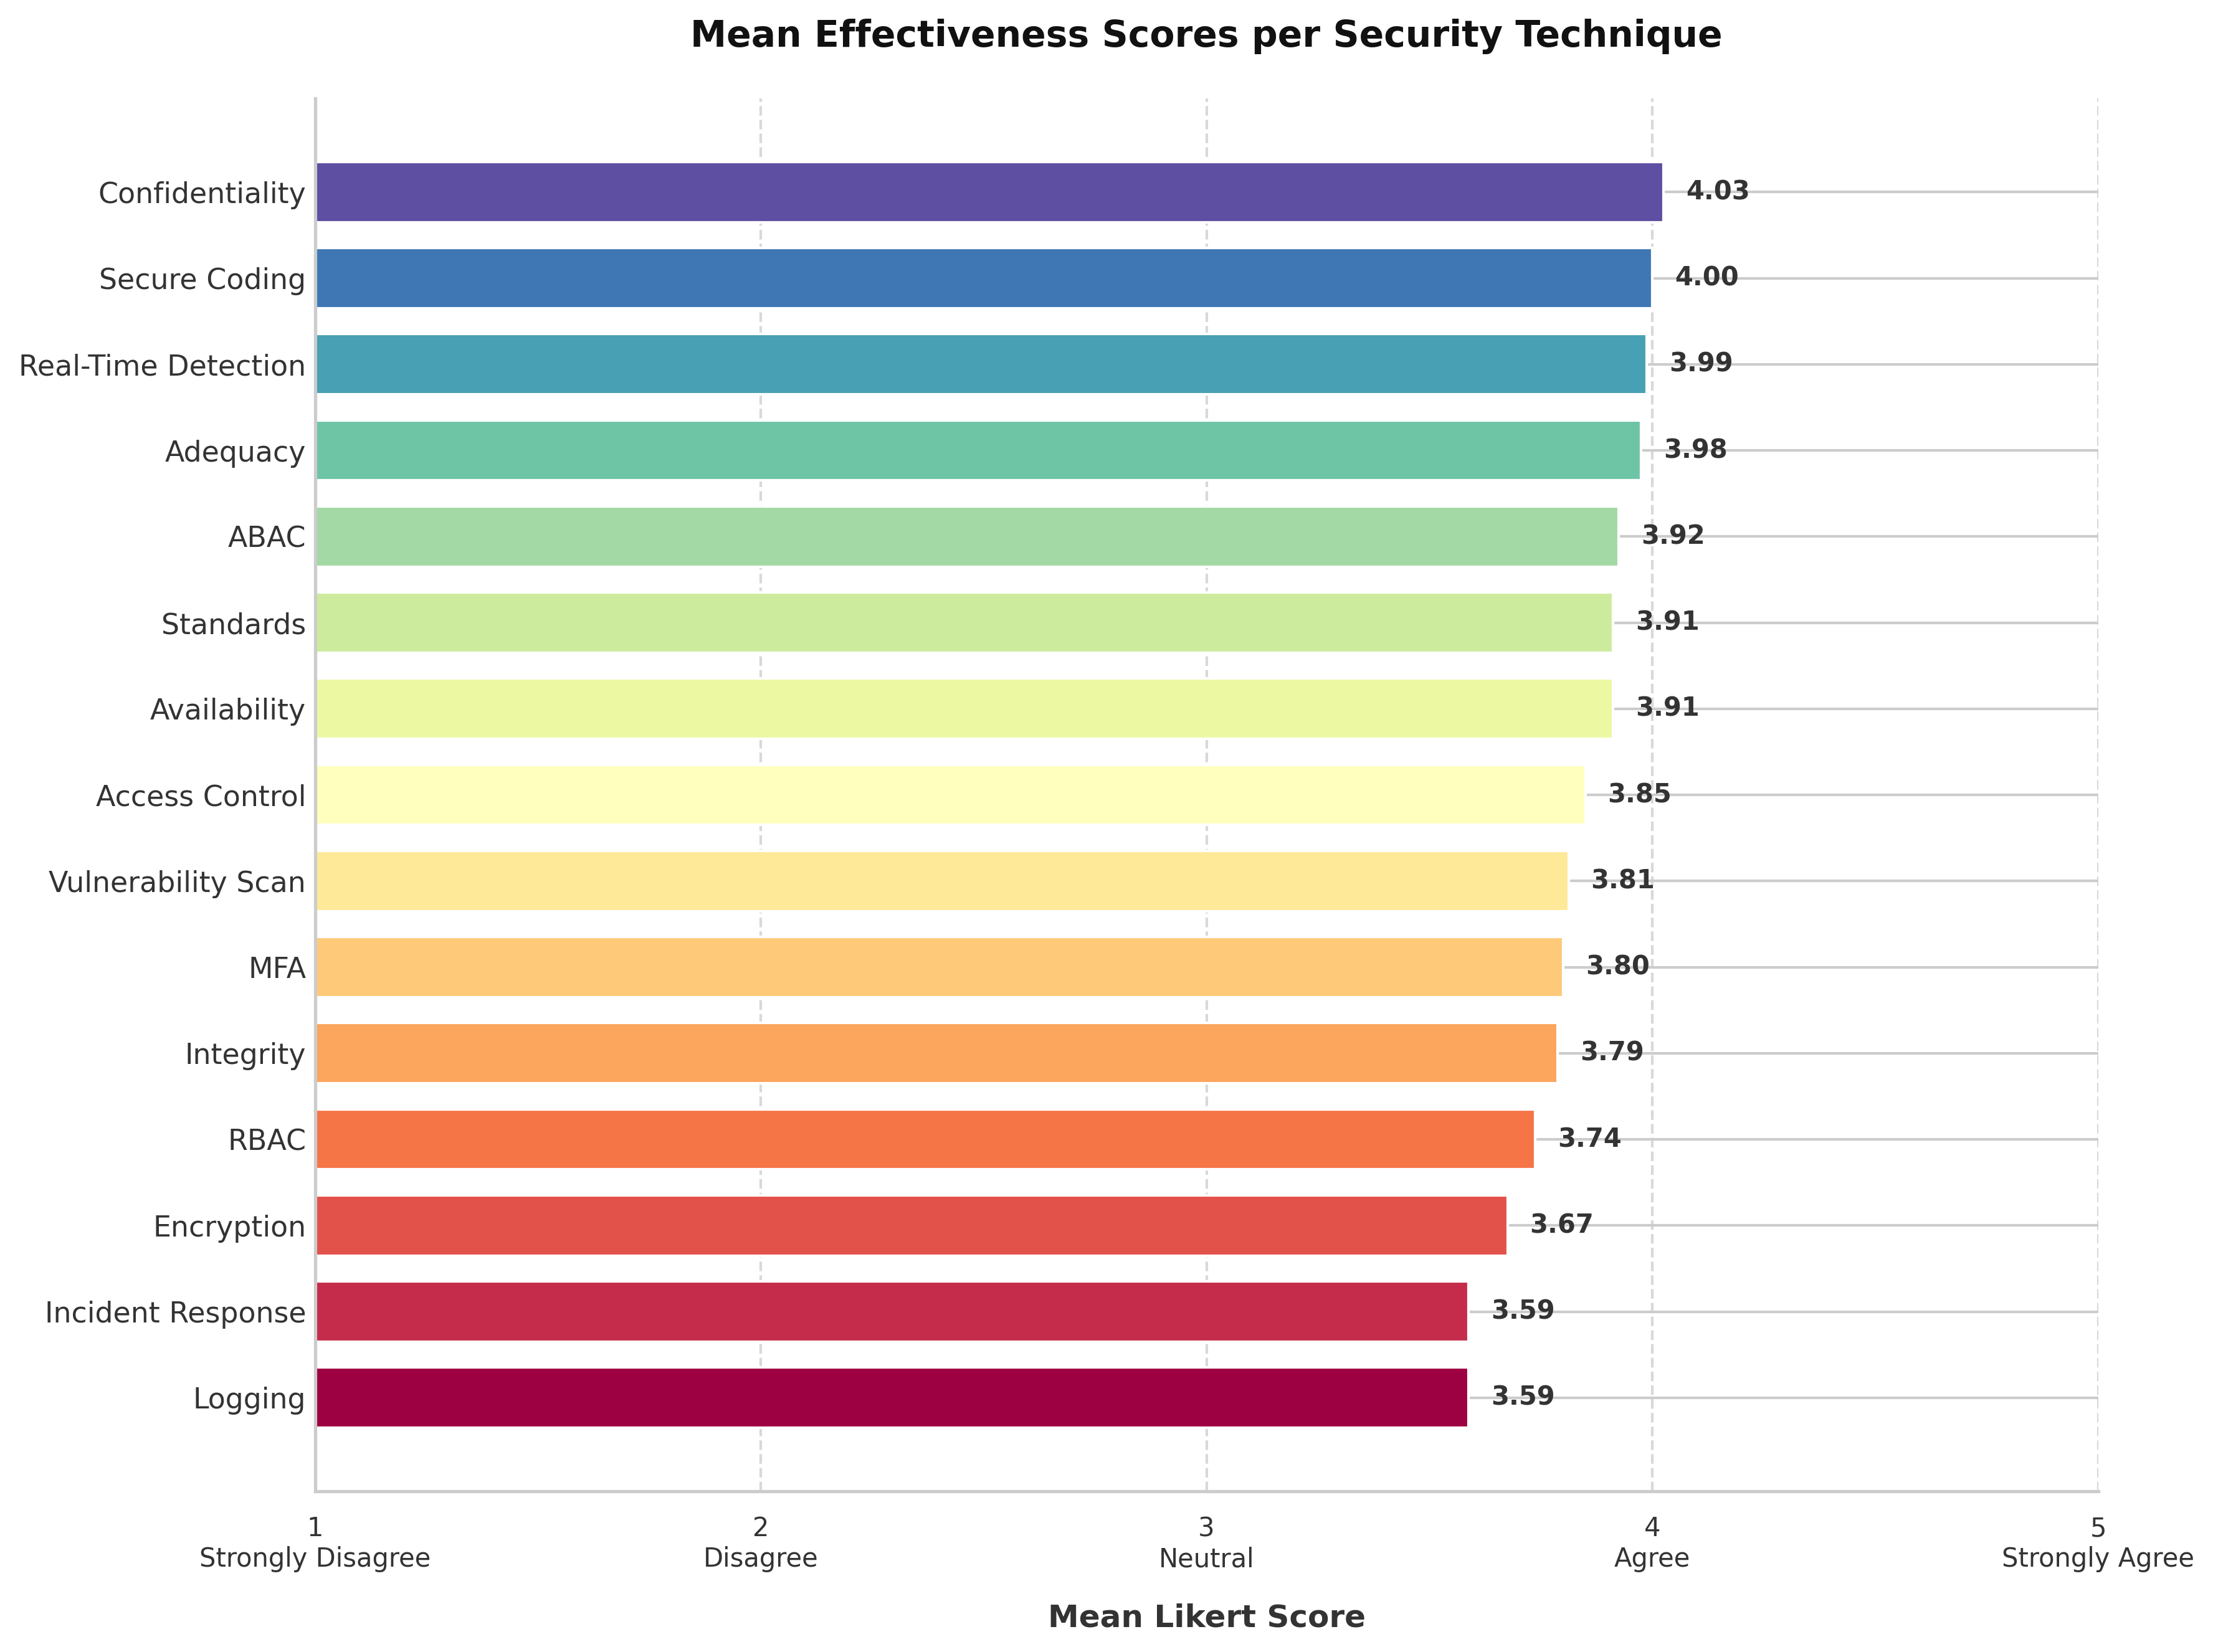

In [ ]:
# 2. Define target survey columns
control_cols = [
    "Encryption effectively protects sensitive data.",
    "Multi-Factor Authentication improves security.",
    "Role-Based Access Control enhances access management.",
    "Attribute-Based Access Control provides flexible security.",
    "Secure coding practices reduce application vulnerabilities.",
    "Security logging assists incident investigations.",
    "Regular vulnerability scanning improves security posture.",
    "Current security controls adequately protect sensitive information.",
    "Existing security measures detect attacks in real time.",
    "Security controls minimize unauthorized access.",
    "Incident response mechanisms are effective.",
    "Current security techniques comply with security standards.",
    "Existing protection techniques ensure confidentiality.",
    "Existing protection techniques ensure integrity.",
    "Existing protection techniques ensure availability."
]

# 3. Map Likert text entries to numeric weights
likert_map = {"Strongly Agree": 5, "Agree": 4, "Neutral": 3, "Disagree": 2, "Strongly Disagree": 1}

numeric_df = df[control_cols].copy()
for col in control_cols:
    numeric_df[col] = numeric_df[col].map(likert_map)

# 4. Use concise, impactful labels for high-quality article output
short_labels = {
    "Encryption effectively protects sensitive data.": "Encryption",
    "Multi-Factor Authentication improves security.": "MFA",
    "Role-Based Access Control enhances access management.": "RBAC",
    "Attribute-Based Access Control provides flexible security.": "ABAC",
    "Secure coding practices reduce application vulnerabilities.": "Secure Coding",
    "Security logging assists incident investigations.": "Logging",
    "Regular vulnerability scanning improves security posture.": "Vulnerability Scan",
    "Current security controls adequately protect sensitive information.": "Adequacy",
    "Existing security measures detect attacks in real time.": "Real-Time Detection",
    "Security controls minimize unauthorized access.": "Access Control",
    "Incident response mechanisms are effective.": "Incident Response",
    "Current security techniques comply with security standards.": "Standards",
    "Existing protection techniques ensure confidentiality.": "Confidentiality",
    "Existing protection techniques ensure integrity.": "Integrity",
    "Existing protection techniques ensure availability.": "Availability"
}

# 5. Calculate means and sort ascending
means = numeric_df.mean().rename(index=short_labels).sort_values(ascending=True)

# 6. Generate vibrant colors using the 'Spectral' map
cmap = plt.get_cmap('Spectral')
colors = [cmap(i) for i in np.linspace(0, 1, len(means))]

# 7. Build the plot
fig, ax = plt.subplots(figsize=(12, 9), dpi=300)
bars = ax.barh(means.index, means.values, color=colors, edgecolor='white', height=0.7)

# Aesthetic Styling
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')
ax.grid(axis='x', linestyle='--', alpha=0.3, color='gray')

# Formatting Ticks and Labels
ax.set_xlim(1.0, 5.0)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xticklabels(['1\nStrongly Disagree', '2\nDisagree', '3\nNeutral', '4\nAgree', '5\nStrongly Agree'],
                   fontsize=10, color='#333333')
ax.tick_params(axis='y', which='both', length=0, labelsize=11, labelcolor='#333333')

ax.set_xlabel('Mean Likert Score', fontsize=12, fontweight='bold', labelpad=12, color='#333333')
ax.set_title('Mean Effectiveness Scores per Security Technique', fontsize=14, fontweight='bold', pad=20, color='#111111')

# Add score labels at the end of each bar
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.05, bar.get_y() + bar.get_height()/2, f'{width:.2f}',
            va='center', ha='left', fontsize=10, fontweight='bold', color='#333333')

plt.tight_layout()
plt.savefig("vibrant_security_controls_bar.png", dpi=300, bbox_inches='tight')

In [ ]:
# 2. Define target columns
assessment_tool_cols = [
    "Security assessment tools accurately detect vulnerabilities.",
    "Security scans are completed within acceptable time.",
    "Security reports are easy to understand.",
    "Assessment tools generate reliable results."
]

# 3. Map Likert responses to numerical values
likert_map = {"Strongly Agree": 5, "Agree": 4, "Neutral": 3, "Disagree": 2, "Strongly Disagree": 1}

numeric_df = df[assessment_tool_cols].copy()
for col in assessment_tool_cols:
    numeric_df[col] = numeric_df[col].map(likert_map)

# 4. Compute mean scores for the pie chart
means = numeric_df.mean()
short_labels = [
    "Accurate Detection",
    "Scan Efficiency",
    "Report Clarity",
    "Result Reliability"
]

# 5. Create the Pie Chart
fig, ax = plt.subplots(figsize=(8, 8), dpi=300)
wedges, texts, autotexts = ax.pie(
    means,
    labels=short_labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Paired(range(len(means))),
    wedgeprops={'edgecolor': 'white'}
)

# Styling for readability
plt.setp(autotexts, size=12, weight="bold", color="white")
plt.setp(texts, size=12)

ax.set_title('Evaluation Weights of Security Assessment Tool Criteria', fontsize=14, fontweight='bold')
plt.tight_layout()

# Save the plot
plt.savefig("assessment_tools_evaluation_pie.png", dpi=300, bbox_inches='tight')
plt.close()

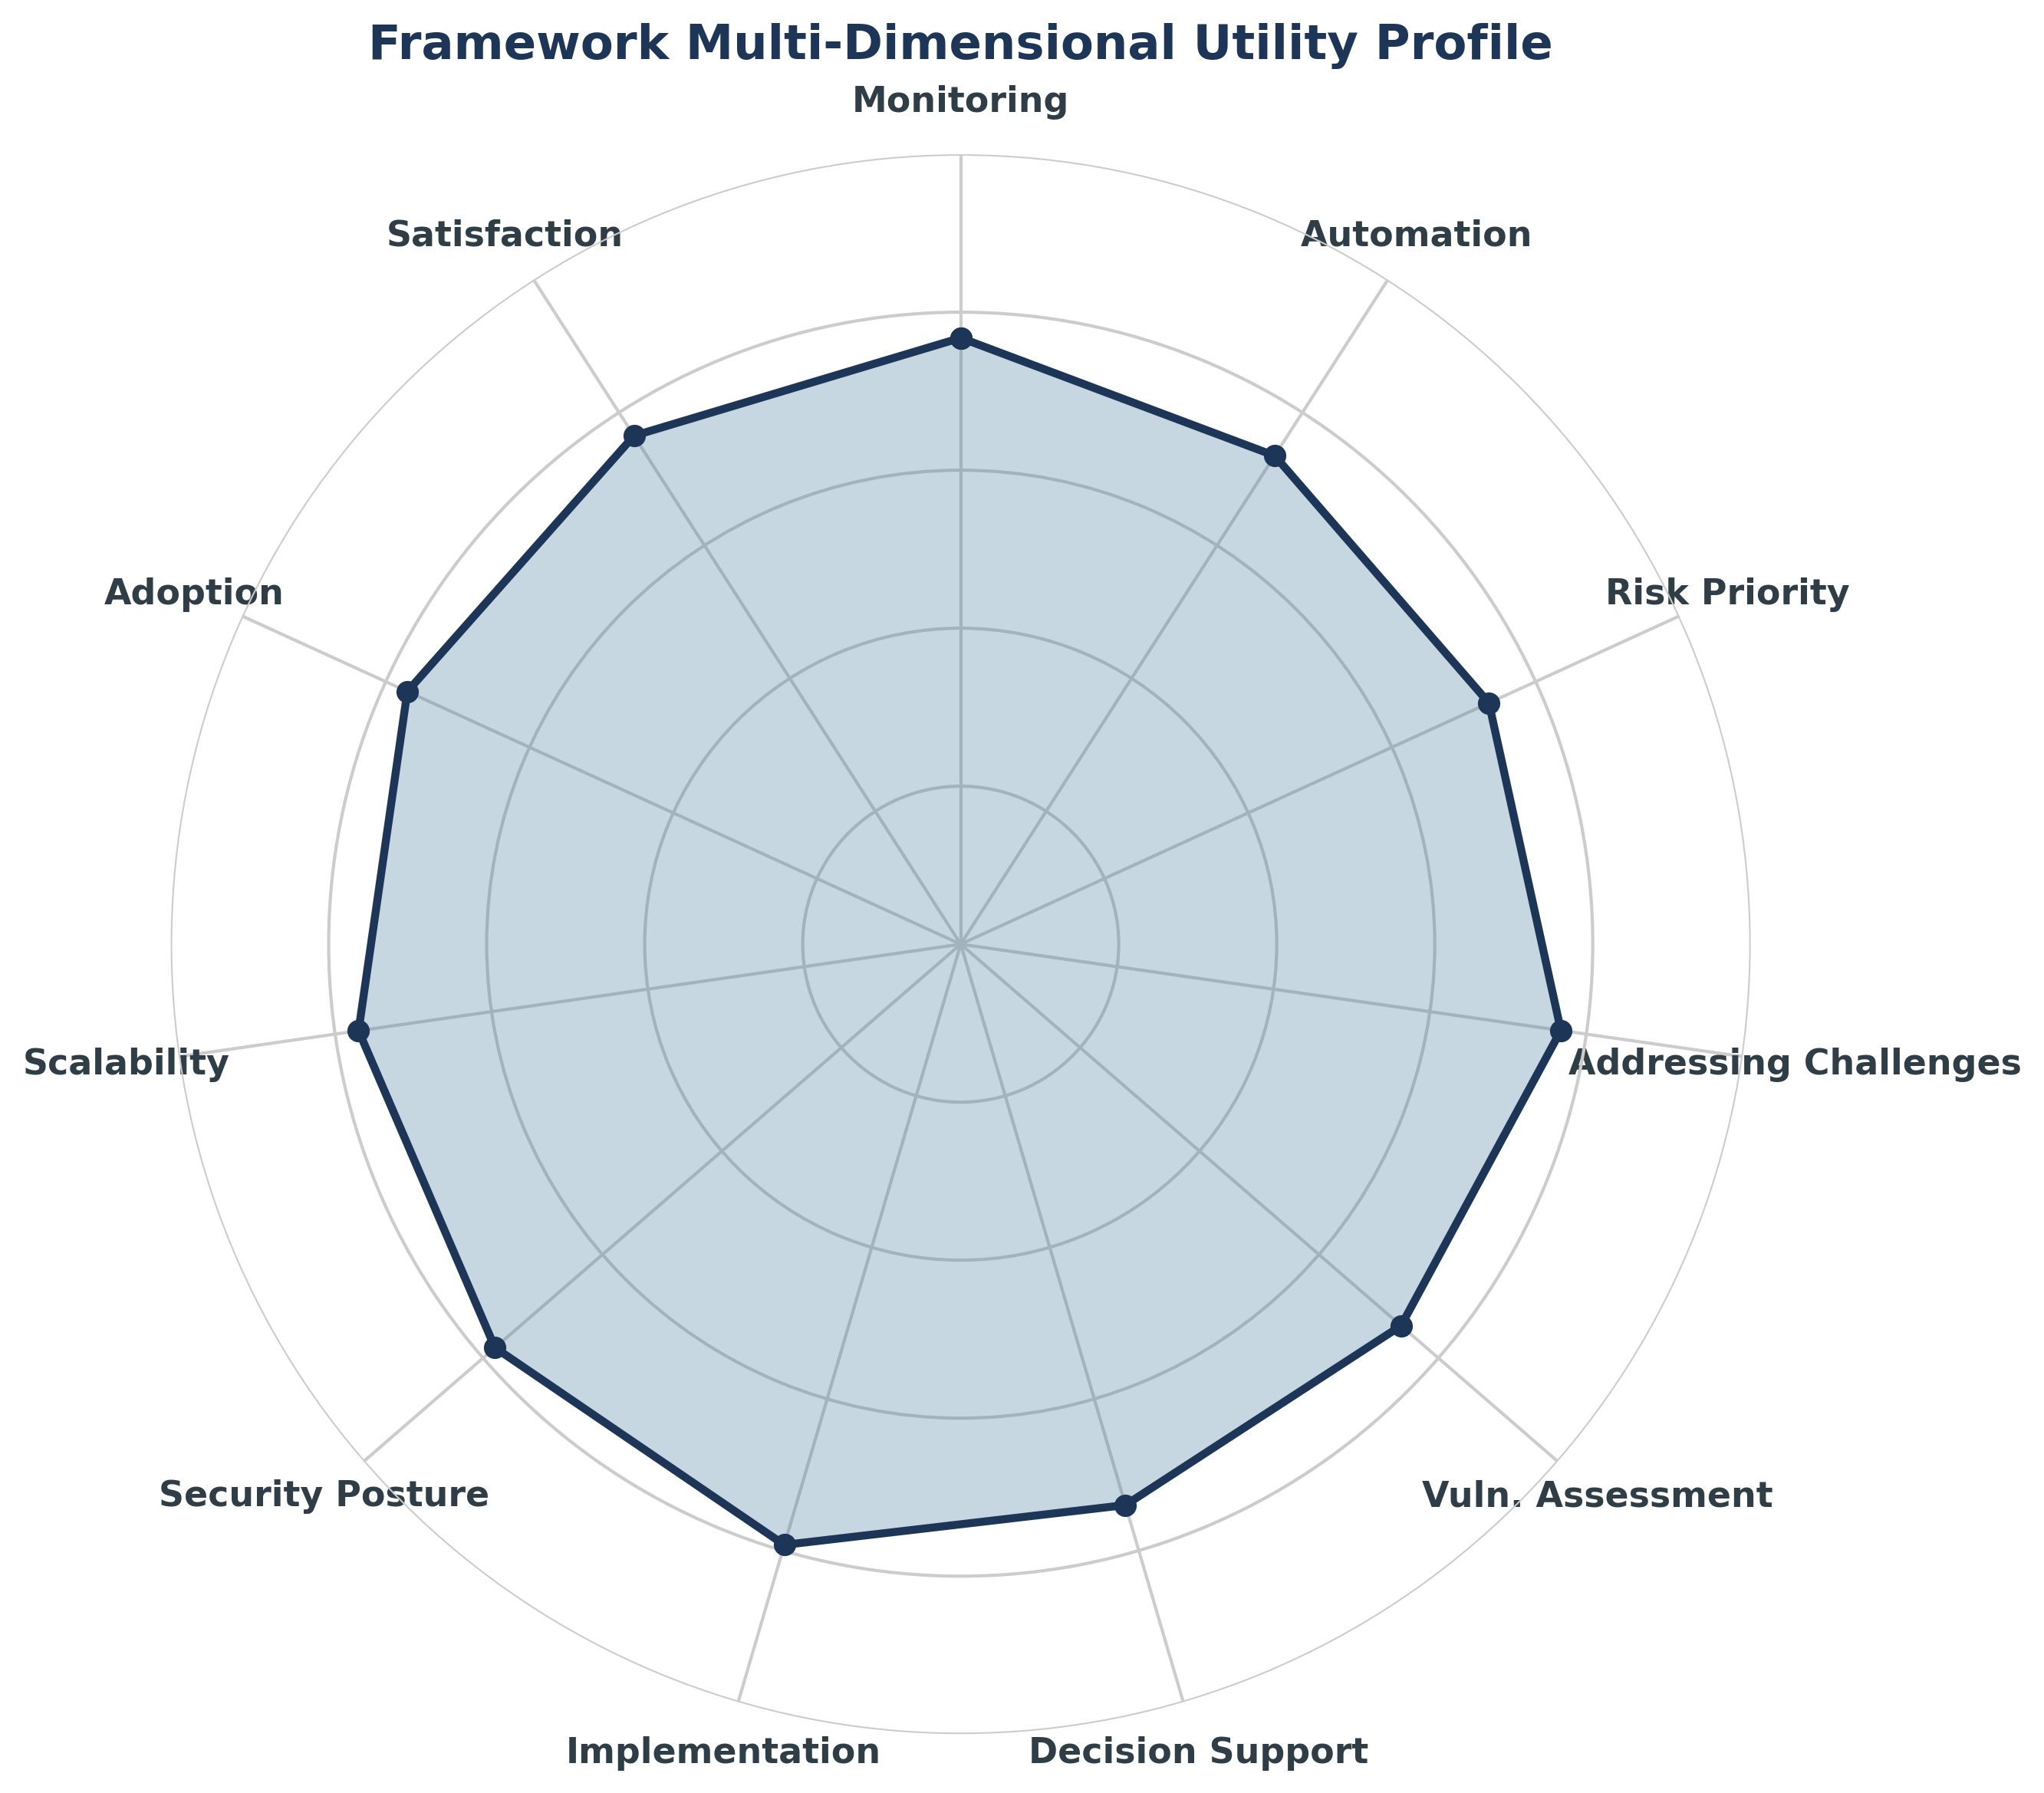

In [ ]:
# 2. Define the criteria evaluating your proposed framework
framework_cols = [
    "The framework should support continuous monitoring.",
    "Automated security assessment improves application security.",
    "Risk prioritization helps organizations respond faster.",
    "The proposed framework addresses major application security challenges.",
    "The framework can improve vulnerability assessment.",
    "The framework supports better security decision-making.",
    "The framework is easy to implement.",
    "The framework can improve organizational security posture.",
    "The framework is scalable.",
    "The framework should be adopted by organizations.",
    "Overall, I am satisfied with the proposed framework."
]

# Map Likert responses (1-5)
likert_map = {"Strongly Agree": 5, "Agree": 4, "Neutral": 3, "Disagree": 2, "Strongly Disagree": 1}
numeric_df = df[framework_cols].copy()
for col in framework_cols:
    numeric_df[col] = numeric_df[col].map(likert_map)

# 3. Calculate Mean Scores
means = numeric_df.mean().values
labels = [
    "Monitoring", "Automation", "Risk Priority", "Addressing Challenges",
    "Vuln. Assessment", "Decision Support", "Implementation",
    "Security Posture", "Scalability", "Adoption", "Satisfaction"
]

# 4. Create the Radar Chart
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # Close the loop
stats = np.concatenate((means, [means[0]]))

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True), dpi=300)

# Fill and plot
ax.fill(angles, stats, color='#457B9D', alpha=0.3)
ax.plot(angles, stats, color='#1D3557', linewidth=2.5, marker='o')

# Grid and Labels
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11, fontweight='bold', color='#2F3E46')
ax.set_ylim(0, 5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(['', '', '', '', ''], color='gray') # Hide numbers for clean look

# Style
ax.spines['polar'].set_visible(False)
ax.set_title("Framework Multi-Dimensional Utility Profile", fontsize=15, fontweight='bold', pad=30, color='#1D3557')

plt.tight_layout()
plt.savefig("framework_radar_profile.png", dpi=300)